# MicrobeAtlas Metal–Microbial Community Analysis (v3)
**Goal:** Identify soil bacterial OTUs robustly and positively associated with
      soil metal concentrations after comprehensive covariate control,
      including mutual adjustment for other metals.

#### Key design decisions:
- **Full-composition CLR:** geometric mean computed over **ALL OTUs**; CLR of
    sub-compositions for test-set OTUs uses the full-composition GM.
- Library size (log10 total reads) as a covariate.
- Project batch effect controlled via dummy variables; dummies excluded
    from VIF screening (scale-incompatible with continuous covariates).
- Spearman inter-metal correlation matrix for collinearity warnings.
- Metals log10-transformed before Pearson/VIF checks (log-normal assumption).
- Negative metal concentrations treated as missing (detection-limit coding).
- Permutation minimum resolvable p = 1/N_PERMUTATION documented explicitly.
- **Bootstrap CI:** 1000 replicates, percentile method; limitation noted.
- BH FDR applied per-metal; global FDR applied secondarily.
- **OTU selection:** top variance *among prevalent OTUs*, with sensitivity note.
- Missingness-at-random check for metal data.

In [1]:
import sys, os, pickle, logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, rankdata, pearsonr
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pyspark.sql import functions as F, SparkSession
from pyspark.sql.window import Window
from tqdm import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Selective warning filters (do NOT silence all warnings) ──────────────────
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger(__name__)

spark = get_spark_session()

PROJ_ROOT = Path.cwd().parent
DATA_DIR = PROJ_ROOT / 'data'
FIG_DIR  = PROJ_ROOT / 'figures'
for d in [DATA_DIR, FIG_DIR]:
    d.mkdir(exist_ok=True)

sns.set_style("white")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150, 'savefig.dpi': 300})
pd.set_option('display.max_columns', None)

2026-06-19 05:28:41,239 INFO HTTP Request: GET http://mms.prod:8000/workspaces/me/sql-warehouse-prefix "HTTP/1.1 200 OK"


In [2]:
# ─── Configuration ────────────────────────────────────────────────────────────
CONFIG = {
    # Read-depth filter
    'MIN_READS': 1000,
    # OTU prevalence for CLR denominator composition (≥5 % of samples recommended;
    # 0.1 % risks including sequence-error OTUs in the geometric mean)
    'PREVALENCE_CUT_PRE_CLR': 0.05,   # fraction of samples
    # OTU prevalence for association testing (≥1 %)
    'PREVALENCE_CUT_TEST': 0.01,
    'MAX_OTUS_FOR_TEST': 2000,
    'FDR_ALPHA': 0.05,
    # 1000 bootstrap replicates for 95 % percentile CI; 2000+ preferred for BCa
    # 200: not ideal, but prevents excessive computation time
    'N_BOOTSTRAP': 200,
    # 9999 permutations → minimum resolvable p ≈ 1e-4; noted in interpretation
    'N_PERMUTATION': 9999,
    # Minimum |partial r| for biological relevance (arbitrary; see sensitivity)
    'EFFECT_SIZE_MIN': 0.1,
    'METALS': ["Co", "Cr", "Cu", "Ni", "Zn", "Pb", "As", "Cd", "Hg"],
    # VIF threshold for *continuous* covariates only (project dummies excluded)
    'COVARIATE_VIF_THRESHOLD': 10,    # conventional threshold
    # Spearman |r| at which inter-metal collinearity warrants a warning
    'METAL_CORR_WARN': 0.7,
    # Global random seed for full reproducibility
    'SEED': 42,
}

log.info("Configuration loaded. SEED=%d, N_PERMUTATION=%d, N_BOOTSTRAP=%d",
         CONFIG['SEED'], CONFIG['N_PERMUTATION'], CONFIG['N_BOOTSTRAP'])
log.info("Permutation minimum resolvable p-value: %.4g", 1 / CONFIG['N_PERMUTATION'])

2026-06-19 05:28:49,929 INFO Configuration loaded. SEED=42, N_PERMUTATION=9999, N_BOOTSTRAP=200


2026-06-19 05:28:49,930 INFO Permutation minimum resolvable p-value: 0.0001


In [3]:
# ─── Helper Functions ─────────────────────────────────────────────────────────

# Implement proper multiplicative replacement
def multiplicative_replacement(rel_abund, delta=0.65):
    """
    Row‑wise multiplicative replacement (reference implementation).

    The actual Spark CLR pipeline (Cell 7) uses an equivalent Spark‑native
    transformation (groupBy + withColumn) to parallelise this operation.
    This function is kept for standalone / verification use.
    """
    for row_idx in range(rel_abund.shape[0]):
        row = rel_abund[row_idx, :]
        zero_mask = row == 0
        if zero_mask.any():
            min_pos = np.min(row[~zero_mask])
            replacement = delta * min_pos
            scale = (1 - replacement * zero_mask.sum()) / row[~zero_mask].sum()
            row[~zero_mask] *= scale
            row[zero_mask] = replacement
    return rel_abund


def clr_transform(rel_abund: np.ndarray) -> np.ndarray:
    """
    Centered log-ratio (CLR) transformation.

    The geometric mean (GM) is computed over ALL columns (full composition).
    Caller must ensure no zeros exist (apply multiplicative_replacement first).

    Raises ValueError if any zero or negative entry is found.
    """
    if np.any(rel_abund <= 0):
        raise ValueError(
            "clr_transform requires strictly positive values. "
            "Apply multiplicative_replacement before calling."
        )
    log_x = np.log(rel_abund)
    gm_log = log_x.mean(axis=1, keepdims=True)   # log of geometric mean
    return log_x - gm_log


def compute_vif(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute VIF for each column of df.

    The design matrix is augmented with a constant column (intercept) as
    required by statsmodels.variance_inflation_factor.
    """
    X = np.column_stack([np.ones(len(df)), df.values])
    vif = pd.DataFrame({
        "variable": df.columns,
        "VIF": [variance_inflation_factor(X, i + 1) for i in range(df.shape[1])]
    })
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


def residualise_ranks(Y: np.ndarray, Z_rank: np.ndarray) -> np.ndarray:
    """
    Return residuals of rank(Y) on rank(Z) via OLS.

    Parameters
    ----------
    Y       : (n, p) array — variables to residualise.
    Z_rank  : (n, q) array — *already ranked* covariates (compute once, reuse).

    Returns
    -------
    Y_res : (n, p) rank residuals.
    """
    Y_rank = np.apply_along_axis(rankdata, 0, Y)
    Z_design = np.column_stack([np.ones(Z_rank.shape[0]), Z_rank])
    # rcond=None uses machine-epsilon cutoff; warn on near-rank-deficiency
    beta, residuals, rank, sv = np.linalg.lstsq(Z_design, Y_rank, rcond=None)
    expected_rank = Z_design.shape[1]
    if rank < expected_rank:
        log.warning("Z_design is rank-deficient (%d < %d); some covariates are collinear.", rank, expected_rank)
    Y_pred = Z_design @ beta
    return Y_rank - Y_pred


def partial_spearman_matrix_resid(
    x: np.ndarray,
    Y: np.ndarray,
    Z: np.ndarray,
    n_perm: int = 5000,
    seed: int = None,
    pca_components: int = None, 
) -> tuple[np.ndarray, np.ndarray]:
    
    rng = np.random.default_rng(seed)
    n = len(x)

    # PCA Dimensionality Reduction
    if pca_components is not None:
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler
        # Standardize Z (it's already partially scaled, but this ensures proper PCA)
        scaler = StandardScaler()
        Z_scaled = scaler.fit_transform(Z)
        # Fit PCA
        pca = PCA(n_components=pca_components)
        Z = pca.fit_transform(Z_scaled)

    # Rank Z once; reuse for both x and Y residualisation
    Z_rank = np.apply_along_axis(rankdata, 0, Z)
    Z_design = np.column_stack([np.ones(n), Z_rank])

    # Residualise Y
    Y_res = residualise_ranks(Y, Z_rank)

    # Residualise x
    x_rank = rankdata(x)
    beta_x, _, rank_x, _ = np.linalg.lstsq(Z_design, x_rank, rcond=None)
    if rank_x < Z_design.shape[1]:
        log.warning("Z_design rank-deficient when residualising x.")
    x_res = x_rank - Z_design @ beta_x

    # Standardise for dot-product correlation
    x_std = (x_res - x_res.mean()) / (x_res.std(ddof=1) + 1e-300)
    denom = Y_res.std(axis=0, ddof=1) + 1e-300
    Y_std = (Y_res - Y_res.mean(axis=0)) / denom
    r_obs = (x_std @ Y_std) / (n - 1)

    if n_perm == 0:
        return r_obs, np.full(Y.shape[1], np.nan)

    perm_stats = np.empty((n_perm, Y.shape[1]))
    for i in range(n_perm):
        perm_x = rng.permutation(x_std)
        perm_stats[i] = perm_x @ Y_std / (n - 1)

    p_perm = (np.abs(perm_stats) >= np.abs(r_obs)).mean(axis=0)
    return r_obs, p_perm


def bootstrap_partial_corr(
    x: np.ndarray,
    Y: np.ndarray,
    Z: np.ndarray,
    otu_idx: int,
    n_boot: int = 1000,
    seed: int = 42,
    pca_components: int = None, 
) -> tuple[np.ndarray, float]:
    
    rng = np.random.default_rng(seed)
    n = len(x)
    y = Y[:, otu_idx]
    boot_r = np.empty(n_boot)

    # Apply PCA to Z if requested 
    if pca_components is not None:
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        Z_scaled = scaler.fit_transform(Z)
        pca = PCA(n_components=pca_components)
        Z = pca.fit_transform(Z_scaled)

    for b in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        xb = x[idx]; yb = y[idx]; Zb = Z[idx]
        if Zb.shape[1] + 2 >= n:
            boot_r[b] = np.nan
            continue
        Z_rank_b = np.apply_along_axis(rankdata, 0, Zb)
        Z_design_b = np.column_stack([np.ones(n), Z_rank_b])
        xr = rankdata(xb); yr = rankdata(yb)
        beta_x = np.linalg.lstsq(Z_design_b, xr, rcond=None)[0]
        beta_y = np.linalg.lstsq(Z_design_b, yr, rcond=None)[0]
        rx = xr - Z_design_b @ beta_x
        ry = yr - Z_design_b @ beta_y
        if rx.std() < 1e-10 or ry.std() < 1e-10:
            boot_r[b] = np.nan
            continue
        boot_r[b] = pearsonr(rx, ry)[0]

    valid = boot_r[~np.isnan(boot_r)]
    if len(valid) < 0.8 * n_boot:
        log.warning(">20%% of bootstrap replicates failed (rank deficiency or zero variance).")
    ci = np.nanpercentile(boot_r, [2.5, 97.5])
    se = np.nanstd(boot_r)
    return ci, se

def _boot_row_single(row, pca_components: int = None):
    """Compute bootstrap CI for a single OTU‑metal row, using PCA on Z."""
    metal = row["exposure"]
    otu_id = row["otu_id"]
    idx = common_idx[complete_metal_mask.values]
    other_metals = [m for m in CONFIG["METALS"] if m != metal]
    Z_other = geo_metals_scaled.loc[idx, other_metals].values
    Z = np.column_stack([cov_matrix_scaled.loc[idx].values, Z_other])
    x = geo_metals_pd.loc[idx, metal].values
    y = clr_test.loc[idx, otu_id].values.reshape(-1, 1)
    otu_idx = list(top_otus).index(otu_id)
    ci, se = bootstrap_partial_corr(
        x, y, Z, otu_idx,
        n_boot=CONFIG['N_BOOTSTRAP'],
        seed=int(np.random.default_rng().integers(1_000_000)),
        pca_components=pca_components,            
    )
    return {
        "otu_id": otu_id, "exposure": metal,
        "ci_lower": ci[0], "ci_upper": ci[1], "boot_se": se,
    }

In [4]:
# ─── 1. Load and filter soil samples ─────────────────────────────────────────

log.info("Loading and filtering soil samples …")
meta       = spark.table("arkinlab_microbeatlas.sample_metadata")
enriched   = spark.table("arkinlab_microbeatlas.enriched_metadata")
gee        = spark.table("arkinlab_microbeatlas.enriched_metadata_gee")
otu_counts = spark.table("arkinlab_microbeatlas.otu_counts_long")
otu_tax    = spark.table("arkinlab_microbeatlas.otu_metadata")

# Soil samples with valid coordinates
# Pattern for a numeric string (including scientific notation, signs, decimals)
# This allows leading/trailing spaces (trimmed automatically by cast) but we keep it strict.
numeric_pattern = r"^[+-]?\d*\.?\d+(?:[eE][+-]?\d+)?$"

soil = (meta
    .filter(F.lower(F.col("Environments")).contains("soil"))
    .withColumn(
        "lat",
        F.when(F.col("LatitudeParsed").rlike(numeric_pattern),
               F.col("LatitudeParsed").cast("double"))
    )
    .withColumn(
        "lon",
        F.when(F.col("LongitudeParsed").rlike(numeric_pattern),
               F.col("LongitudeParsed").cast("double"))
    )
    .filter(
        F.col("lat").isNotNull() & F.col("lon").isNotNull() &
        F.col("lat").between(-90, 90) &
        F.col("lon").between(-180, 180)
    )
    .select("sample_id", "lat", "lon")
)

# Total reads over ALL OTUs — used as CLR denominator and library-size covariate
total_reads_all = (otu_counts
    .groupBy("sample_id")
    .agg(F.sum("count").alias("total_reads"))
)
soil = (soil
    .join(total_reads_all, "sample_id", "inner")
    .filter(F.col("total_reads") >= CONFIG['MIN_READS'])
)
soil_pd = soil.toPandas()
log.info("Soil samples after read-depth filter: %d", len(soil_pd))

# GeoROC metals — retain samples with at least one non-null metal
metal_col_exprs = [
    F.col(f"GeoROC_Rocks_georoc_{m}_ppm").cast("float").alias(m)
    for m in CONFIG['METALS']
]
any_metal = None
for m in CONFIG['METALS']:
    c = F.col(f"GeoROC_Rocks_georoc_{m}_ppm").isNotNull()
    any_metal = c if any_metal is None else (any_metal | c)

soil_ids = soil.select("sample_id")
geo_metals_spark = (enriched
    .join(soil_ids, enriched.accession_id == soil_ids.sample_id, "inner")
    .filter(any_metal)
    .select(F.col("accession_id").alias("sample_id"), *metal_col_exprs)
)
geo_metals_pd = geo_metals_spark.toPandas().set_index("sample_id")

# Recode negative metal concentrations as missing (detection-limit / analytical artefact)
neg_counts = (geo_metals_pd[CONFIG['METALS']] < 0).sum()
if neg_counts.any():
    log.warning("Negative metal values recoded as NaN:\n%s", neg_counts[neg_counts > 0].to_string())
geo_metals_pd[CONFIG['METALS']] = geo_metals_pd[CONFIG['METALS']].where(
    geo_metals_pd[CONFIG['METALS']] >= 0
)

log.info("Samples with at least one metal value: %d", len(geo_metals_pd))

# Missing data summary
print("\n=== Metal missingness ===")
miss_frac = geo_metals_pd[CONFIG['METALS']].isnull().mean().round(3)
print(miss_frac.to_string())
n_complete = geo_metals_pd[CONFIG['METALS']].notna().all(axis=1).sum()
log.info("Complete cases (all %d metals present): %d", len(CONFIG['METALS']), n_complete)
if n_complete < 50:
    log.warning("Very few complete cases (%d); mutual metal adjustment will have low power.", n_complete)

# Log10 library size — computed here, aligned in Cell 4
log_lib_size_pd = (soil_pd
    .set_index("sample_id")[["total_reads"]]
    .rename(columns={"total_reads": "log_total_reads"})
    .apply(np.log10)
)

2026-06-19 05:28:50,003 INFO Loading and filtering soil samples …


2026-06-19 05:29:19,534 INFO Soil samples after read-depth filter: 224734


2026-06-19 05:29:29,540 INFO Samples with at least one metal value: 77622


2026-06-19 05:29:29,548 INFO Complete cases (all 9 metals present): 354



=== Metal missingness ===
Co    0.339
Cr    0.206
Cu    0.449
Ni    0.161
Zn    0.396
Pb    0.357
As    0.923
Cd    0.963
Hg    0.993


In [5]:
# ─── 2. Build covariate matrix ────────────────────────────────────────────────

log.info("Building covariate matrix …")

# Parse SRS accession from sample_id robustly (some IDs may lack a dot)
soil_pd["srs"] = soil_pd["sample_id"].str.extract(r'\.(\w+)$')[0]
n_no_srs = soil_pd["srs"].isna().sum()
if n_no_srs > 0:
    log.warning("%d sample_ids did not contain a dot; SRS extraction returned NaN for them.", n_no_srs)

# GEE covariates
GEE_VARS = [
    "olm_soil_ph_0cm_H2O", "olm_soil_clay_0cm_pct", "olm_soil_sand_0cm_pct",
    "olm_soil_organic_matter_0cm_pct", "olm_soil_water_content_33kpa_0cm_pct",
    "olm_soil_bulk_density_0cm_g_cm3", "DEM_elevation_m",
    "ERA5_mean_2m_air_temperature_K", "terraclimate_precipitation_mm",
    "NDVI", "EVI",
]
srs_list = soil_pd["srs"].dropna().tolist()
gee_cov = (gee
    .filter(F.col("Sample_ID_Matched").isin(srs_list))
    .select("Sample_ID_Matched", *[c for c in GEE_VARS])
    .dropDuplicates(["Sample_ID_Matched"])
    .toPandas()
    .rename(columns={"Sample_ID_Matched": "srs"})
)
cov_pd = soil_pd.merge(gee_cov, on="srs", how="left")

# Project dummies (top 30 projects → batch-effect control)
proj_map = meta.select("sample_id", "Project").toPandas()
cov_pd = cov_pd.merge(proj_map, on="sample_id", how="left")
top_proj = cov_pd["Project"].value_counts().head(30).index
cov_pd["proj_group"] = cov_pd["Project"].apply(lambda x: x if x in top_proj else "Other")
proj_dum = pd.get_dummies(cov_pd["proj_group"], drop_first=True, prefix="proj")
# Reset index to sample_id before concatenation
proj_dum.index = cov_pd["sample_id"].values

# Spatial terms: sin/cos of lat and lon (meaningful periodicity; avoid lat×lon product)
spatial_df = pd.DataFrame({
    "sin_lat": np.sin(np.radians(cov_pd["lat"].values)),
    "cos_lat": np.cos(np.radians(cov_pd["lat"].values)),
    "sin_lon": np.sin(np.radians(cov_pd["lon"].values)),
    "cos_lon": np.cos(np.radians(cov_pd["lon"].values)),
}, index=cov_pd["sample_id"].tolist())

# Library size
lib_size_df = log_lib_size_pd.reindex(cov_pd["sample_id"].tolist())

# Available GEE variables
avail_gee = [c for c in GEE_VARS if c in cov_pd.columns]
numeric_cov = cov_pd[avail_gee].copy()
numeric_cov.index = cov_pd["sample_id"].tolist()

# Concatenate: continuous | spatial | library size (project dummies kept SEPARATE)
cont_cov = pd.concat([numeric_cov, spatial_df, lib_size_df], axis=1)
cont_cov.index = cov_pd["sample_id"].tolist()

initial_n = len(cont_cov)
cont_cov = cont_cov.dropna()
log.info("Dropped %d samples with missing continuous covariates; %d remain.",
         initial_n - len(cont_cov), len(cont_cov))

# Scale continuous covariates
scaler = StandardScaler()
cont_cov_scaled = pd.DataFrame(
    scaler.fit_transform(cont_cov),
    index=cont_cov.index,
    columns=cont_cov.columns,
)

# ── VIF screening: continuous covariates ONLY (project dummies excluded) ──────
# VIF with intercept: compute_vif adds the intercept column internally.
vif_thresh = CONFIG['COVARIATE_VIF_THRESHOLD']
log.info("Iterative VIF removal on continuous covariates (threshold=%d):", vif_thresh)
vif_cov = cont_cov_scaled.copy()
dropped_for_vif = []

# Protect pH from automatic removal (strongest single predictor of soil microbiome)
PROTECTED_VARS = {"olm_soil_ph_0cm_H2O"}

max_vif = float('inf')
while max_vif > vif_thresh:
    vif_df = compute_vif(vif_cov)
    max_vif = vif_df["VIF"].iloc[0]
    if max_vif > vif_thresh:
        candidate = vif_df.iloc[0]["variable"]
        if candidate in PROTECTED_VARS:
            # Try next highest VIF that is not protected
            for _, row in vif_df.iterrows():
                if row["variable"] not in PROTECTED_VARS:
                    candidate = row["variable"]
                    break
            else:
                log.warning("All high-VIF variables are protected; stopping VIF removal at VIF=%.1f", max_vif)
                break
        log.info("  Dropping '%s' (VIF=%.1f)", candidate, max_vif)
        dropped_for_vif.append((candidate, round(max_vif, 1)))
        vif_cov = vif_cov.drop(columns=[candidate])

log.info("VIF-removed variables: %s", dropped_for_vif)
log.info("Retained continuous covariates: %d, max VIF=%.1f", vif_cov.shape[1], max_vif)

# Full covariate matrix: VIF-reduced continuous + project dummies
proj_dum_aligned = proj_dum.reindex(vif_cov.index).fillna(0)
cov_matrix_scaled = pd.concat([vif_cov, proj_dum_aligned], axis=1)

# Save full (pre-VIF) continuous + project set for sensitivity analysis
cont_full_scaled = pd.concat(
    [cont_cov_scaled.reindex(vif_cov.index), proj_dum_aligned], axis=1
)

# Align with metal data
common_idx = cov_matrix_scaled.index.intersection(geo_metals_pd.index)
cov_matrix_scaled = cov_matrix_scaled.loc[common_idx]
cont_full_scaled  = cont_full_scaled.loc[common_idx]
geo_metals_pd     = geo_metals_pd.loc[common_idx]
log.info("Analysis sample size (covariate ∩ metal overlap): %d", len(common_idx))

# Scale other-metals covariates (they enter Z as numeric; rank-based method is
# scale-invariant but scaling improves VIF and numerical conditioning)
metals_scaler = StandardScaler()
geo_metals_scaled = pd.DataFrame(
    metals_scaler.fit_transform(geo_metals_pd[CONFIG['METALS']].fillna(0)),
    index=geo_metals_pd.index, columns=CONFIG['METALS'],
)
# (NaN-filled-with-0 for scaling only; actual analysis uses complete-case masking)

# ── Inter-metal collinearity: Spearman r (appropriate for right-skewed data) ──
metal_spearman = geo_metals_pd[CONFIG['METALS']].rank().corr()
print("\nInter-metal Spearman correlations:")
print(metal_spearman.round(2))
high_corr_pairs = [
    (CONFIG['METALS'][i], CONFIG['METALS'][j], round(metal_spearman.iloc[i, j], 2))
    for i in range(len(CONFIG['METALS']))
    for j in range(i + 1, len(CONFIG['METALS']))
    if abs(metal_spearman.iloc[i, j]) > CONFIG['METAL_CORR_WARN']
]
if high_corr_pairs:
    log.warning("High inter-metal Spearman |r| > %.1f — mutual adjustment may be unstable:", CONFIG['METAL_CORR_WARN'])
    for pair in high_corr_pairs:
        log.warning("  %s vs %s: r=%.2f", *pair)

2026-06-19 05:29:29,563 INFO Building covariate matrix …


2026-06-19 05:29:49,555 INFO Dropped 24799 samples with missing continuous covariates; 199935 remain.


2026-06-19 05:29:49,621 INFO Iterative VIF removal on continuous covariates (threshold=10):


2026-06-19 05:30:02,921 INFO   Dropping 'ERA5_mean_2m_air_temperature_K' (VIF=10.3)


2026-06-19 05:30:12,402 INFO VIF-removed variables: [('ERA5_mean_2m_air_temperature_K', np.float64(10.3))]


...

2026-06-19 05:30:12,942 WARNING High inter-metal Spearman |r| > 0.7 — mutual adjustment may be unstable:


2026-06-19 05:30:12,943 WARNING   Co vs Ni: r=0.80


2026-06-19 05:30:12,944 WARNING   Cr vs Ni: r=0.90


2026-06-19 05:30:12,944 WARNING   Cd vs Hg: r=0.79



Inter-metal Spearman correlations:
      Co    Cr    Cu    Ni    Zn    Pb    As    Cd    Hg
Co  1.00  0.69  0.62  0.80  0.39 -0.43 -0.32 -0.20 -0.15
Cr  0.69  1.00  0.55  0.90  0.23 -0.35 -0.12 -0.16 -0.24
Cu  0.62  0.55  1.00  0.59  0.55 -0.41  0.09 -0.10 -0.03
Ni  0.80  0.90  0.59  1.00  0.37 -0.48 -0.08 -0.14 -0.26
Zn  0.39  0.23  0.55  0.37  1.00 -0.25 -0.15  0.20 -0.19
Pb -0.43 -0.35 -0.41 -0.48 -0.25  1.00  0.16  0.38 -0.00
As -0.32 -0.12  0.09 -0.08 -0.15  0.16  1.00  0.48  0.67
Cd -0.20 -0.16 -0.10 -0.14  0.20  0.38  0.48  1.00  0.79
Hg -0.15 -0.24 -0.03 -0.26 -0.19 -0.00  0.67  0.79  1.00


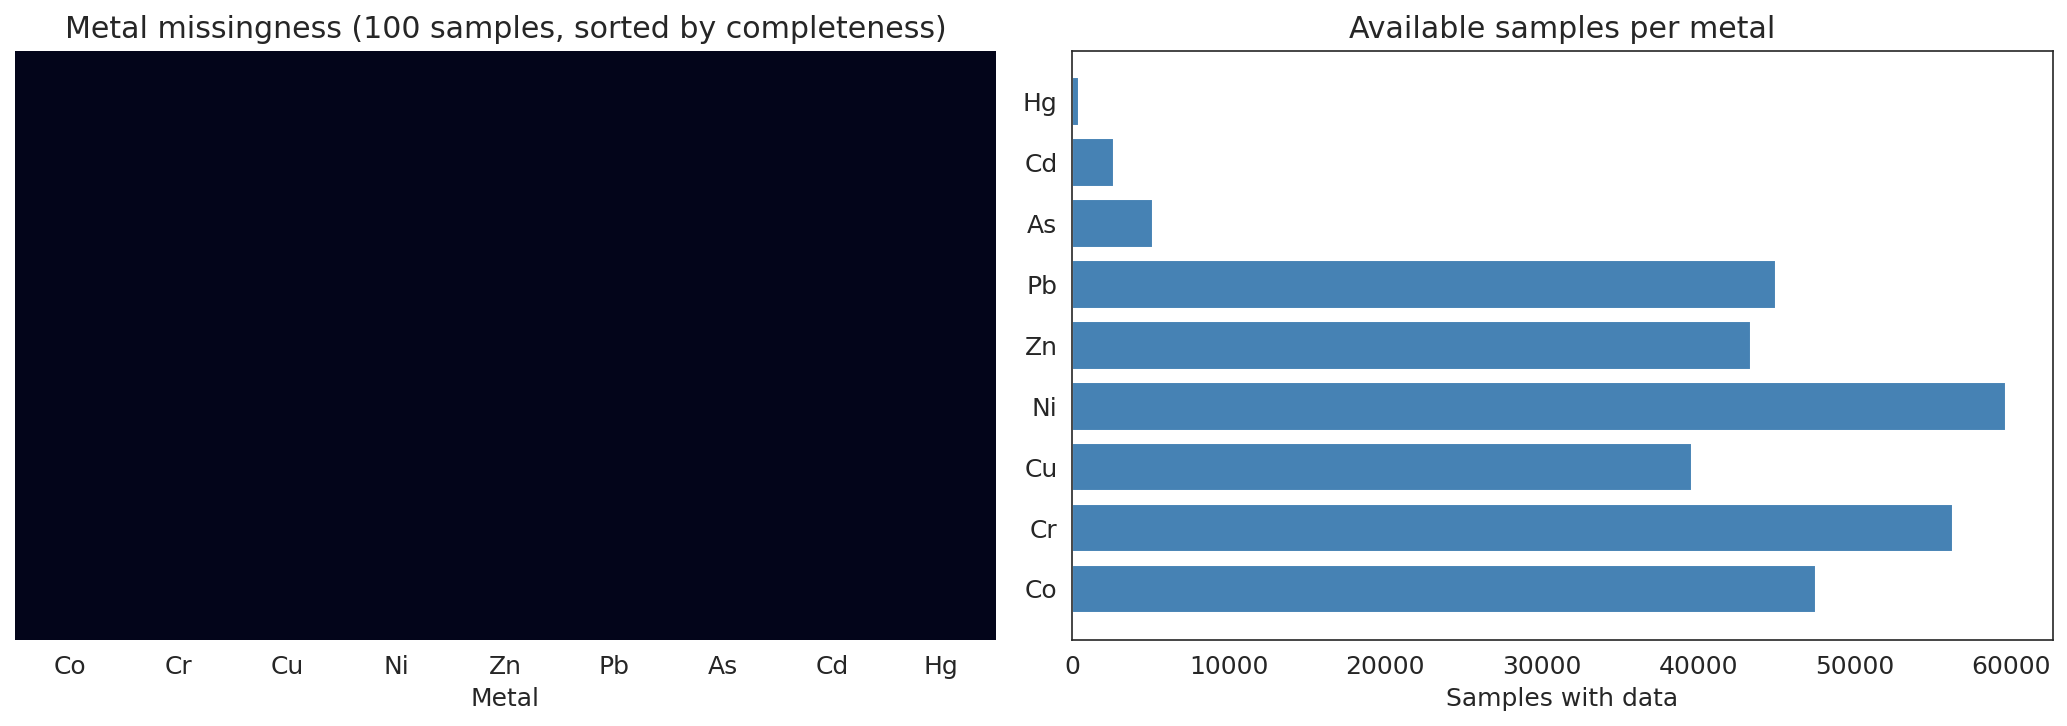


Missingness ~ Project (Spearman r, one metal per row):
  Co : r=-0.021, p=3.78e-08 *** MNAR RISK
  Cr : r=0.031, p=3.7e-16 *** MNAR RISK
  Cu : r=0.014, p=0.000121 *** MNAR RISK
  Ni : r=0.012, p=0.00127 *** MNAR RISK
  Zn : r=0.004, p=0.331
  Pb : r=0.002, p=0.574
  As : r=-0.014, p=0.000196 *** MNAR RISK
  Cd : r=0.025, p=2.57e-11 *** MNAR RISK
  Hg : r=0.026, p=1.6e-12 *** MNAR RISK
Note: Significant association suggests metal data are Missing Not At Random for that project.


In [6]:
# ─── 2b. Missing data diagnostics ────────────────────────────────────────────
# Test whether metal missingness is associated with project or geographic region.
# If missing NOT at random, complete-case analysis is biased.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missingness heatmap — sort samples by number of missing metals for clarity
miss_matrix = geo_metals_pd[CONFIG['METALS']].isnull()
miss_sorted = miss_matrix.loc[miss_matrix.sum(axis=1).sort_values().index]
sns.heatmap(miss_sorted.iloc[:100], cbar=False, ax=axes[0],
            xticklabels=CONFIG['METALS'], yticklabels=False)
axes[0].set_title("Metal missingness (100 samples, sorted by completeness)")
axes[0].set_xlabel("Metal")

# Samples available per metal
avail = geo_metals_pd[CONFIG['METALS']].notna().sum()
axes[1].barh(CONFIG['METALS'], avail.values, color='steelblue')
axes[1].set_xlabel("Samples with data")
axes[1].set_title("Available samples per metal")
plt.tight_layout()
plt.savefig(FIG_DIR / "metal_missingness.png")
plt.show()

# Logistic regression of missingness on project (crude MAR check)
if 'Project' in cov_pd.columns:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import LabelEncoder
    proj_aligned = cov_pd.set_index("sample_id")["Project"].reindex(common_idx)
    le = LabelEncoder()
    proj_enc = le.fit_transform(proj_aligned.fillna("Unknown"))
    print("\nMissingness ~ Project (Spearman r, one metal per row):")
    for m in CONFIG['METALS']:
        miss_indicator = miss_matrix[m].reindex(common_idx).astype(float).fillna(0)
        r, p = spearmanr(proj_enc, miss_indicator)
        flag = " *** MNAR RISK" if p < 0.05 else ""
        print(f"  {m:3s}: r={r:.3f}, p={p:.3g}{flag}")
    print("Note: Significant association suggests metal data are Missing Not At Random for that project.")

In [7]:
# ─── 3. Full-composition CLR ──────────────────────────────────────────────────
# Correct approach: the geometric mean (CLR denominator) is computed over ALL
# OTUs retained by the lenient prevalence filter. The CLR of each OTU is then:
#   clr(x_j) = log(x_j) − mean_j[log(x_j)]
# where mean_j is taken over the FULL composition, not the test sub-set.
# This avoids sub-compositional incoherence.

cache_file = DATA_DIR / "clr_test_matrix.parquet"  #

if os.path.exists(cache_file):
    log.info("Cache found. Loading CLR test matrix from %s", cache_file)
    clr_test = pd.read_parquet(cache_file)   
    # Reconstruct top_otus from the cached CLR matrix columns
    top_otus = clr_test.columns.tolist()
else:
    log.info("No cache file found. Computing CLR from source data…")

    soil_ids_spark = spark.createDataFrame(
        pd.DataFrame({"sample_id": list(common_idx)})
    )
    otu_soil = otu_counts.join(soil_ids_spark, "sample_id", "inner")
    
    # Total reads per sample (all OTUs) — already in soil_pd
    sample_tots = (soil_pd.set_index("sample_id")["total_reads"].reindex(common_idx))
    
    # ── Lenient prevalence filter for CLR composition ─────────────────────────────
    # At least 5% of samples (was 0.1%; 5% balances removing sequencing errors
    # while retaining sufficient compositional context)
    min_prev_clr = max(5, int(len(common_idx) * CONFIG['PREVALENCE_CUT_PRE_CLR']))
    log.info("Lenient prevalence threshold for CLR composition: %d samples (%.1f%%)",
             min_prev_clr, 100 * min_prev_clr / len(common_idx))
    
    otu_prev = (otu_soil
        .groupBy("otu_id")
        .agg(F.countDistinct("sample_id").alias("prevalence"))
        .filter(F.col("prevalence") >= min_prev_clr)
    )
    clr_otu_list = [r.otu_id for r in otu_prev.select("otu_id").collect()]
    log.info("OTUs retained for full composition CLR: %d", len(clr_otu_list))

    # Sample totals 
    sample_tots_spark = spark.createDataFrame(
        sample_tots.reset_index().rename(columns={"index": "sample_id", 0: "total_reads"})
    )
    
    # Filter to OTUs that passed lenient prevalence 
    clr_otus_df = spark.createDataFrame([(oid,) for oid in clr_otu_list], ["otu_id"])
    
    # Build relative abundance in Spark: RA = count / total_reads
    ra_spark = (otu_soil
        .join(clr_otus_df, "otu_id", "inner")
        .join(sample_tots_spark, "sample_id", "inner")
        .withColumn("ra", F.col("count") / F.col("total_reads"))
    )
    
    # Row sums sanity check
    row_sums = ra_spark.groupBy("sample_id").agg(F.sum("ra").alias("row_sum"))
    row_min, row_max = row_sums.select(F.min("row_sum"), F.max("row_sum")).collect()[0]
    log.info("RA row sum range: %.4f – %.4f (expected <1 because rare OTUs excluded from numerator)",
             row_min, row_max)
    
    # Identify samples with all-zero rows (present in row_sums)
    zero_row_rows = row_sums.filter(F.col("row_sum") == 0).select("sample_id").collect()
    zero_row_samples = [row.sample_id for row in zero_row_rows]
    if zero_row_samples:
        log.warning("Found %d samples with zero RA across all retained OTUs. They will receive a pseudocount.",
                    len(zero_row_samples))
    
    # Row‑wise multiplicative replacement in Spark
    #    δ = 0.65 as recommended in the literature.
    #    For each sample:
    #       m_zero      = number of zero entries in the row
    #       min_pos     = smallest positive relative abundance in the row
    #       replace_val = δ * min_pos
    #       scale       = (1 − m_zero * replace_val) / sum(non‑zero entries)
    #    Zeros are set to replace_val; non‑zeros are multiplied by scale.
    
    delta = 0.65
    
    # Per‑sample aggregates
    row_aggs = ra_spark.groupBy("sample_id").agg(
        F.count(F.when(F.col("ra") == 0, 1)).alias("m_zero"),
        F.min(F.when(F.col("ra") > 0, F.col("ra")).otherwise(F.lit(None))).alias("min_pos"),
        F.sum(F.when(F.col("ra") > 0, F.col("ra")).otherwise(0.0)).alias("sum_nonzero"),
    )
    
    # Join back to the RA table and apply the replacement formula
    ra_with_aggs = ra_spark.join(row_aggs, "sample_id")
    
    ra_replaced = ra_with_aggs.withColumn(
        "replace_val", delta * F.col("min_pos")
    ).withColumn(
        "scale_factor",
        F.when(F.col("sum_nonzero") > 0,
               (1.0 - F.col("m_zero") * F.col("replace_val")) / F.col("sum_nonzero"))
        .otherwise(0.0)
    ).withColumn(
        "ra_repl",
        F.when(F.col("ra") == 0, F.col("replace_val"))
         .otherwise(F.col("ra") * F.col("scale_factor"))
    ).select("sample_id", "otu_id", "ra_repl")
    
    log.info("Row‑wise multiplicative replacement applied (δ=%.2f).", delta)
    
    # CLR: log(RA) - mean(log(RA)) per sample
    log_ra = ra_replaced.withColumn("log_ra", F.log("ra_repl"))
    window_spec = Window.partitionBy("sample_id")
    clr_spark = log_ra.withColumn(
        "clr",
        F.col("log_ra") - F.avg("log_ra").over(window_spec)
    )
    
    log.info("Applying CLR (geometric mean over full retained composition) …")
    
    # Variance of CLR per OTU
    otu_variance = clr_spark.groupBy("otu_id").agg(F.variance("clr").alias("variance"))
    
    # Select top `MAX_OTUS_FOR_TEST` OTUs by variance
    top_otus_rows = (otu_variance
        .orderBy(F.desc("variance"))
        .limit(CONFIG['MAX_OTUS_FOR_TEST'])
        .select("otu_id")
        .collect()
    )
    top_otus = [row.otu_id for row in top_otus_rows]
    
    log.info("Selected %d OTUs by top CLR variance for testing.", len(top_otus))
    
    # Collect CLR values for only these OTUs (long format)
    clr_long = (clr_spark
        .filter(F.col("otu_id").isin(top_otus))
        .select("sample_id", "otu_id", "clr")
        .toPandas()
    )
    
    # Pivot to wide format (samples as rows, OTUs as columns)
    clr_test = clr_long.pivot(index="sample_id", columns="otu_id", values="clr")
    
    # Reindex to ensure all samples are present; fill missing samples with 0 (CLR = 0)
    clr_test = clr_test.reindex(common_idx, fill_value=0.0)
    
    # Sanity check: no NaNs
    if clr_test.isna().any().any():
        clr_test = clr_test.fillna(0.0)
        log.warning("Some NaNs remained; filled with 0.0.")

    # Save for next time
    os.makedirs(os.path.dirname(cache_file), exist_ok=True)
    clr_test.to_parquet(cache_file)               
    log.info("CLR test matrix cached to %s", cache_file)

log.info("CLR test matrix shape: %s", clr_test.shape)

2026-06-19 05:30:13,641 INFO Cache found. Loading CLR test matrix from /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/clr_test_matrix.parquet


2026-06-19 05:30:19,326 INFO CLR test matrix shape: (71199, 2000)


In [8]:
# ─── 4. Metal–OTU associations ────────────────────────────────────────────────

cache_file = DATA_DIR / "spearman_results.parquet"   

log.info("Running partial Spearman (9999 permutations, mutual metal adjustment) …")

# Complete-case mask: all metals must be present
complete_metal_mask = geo_metals_pd[CONFIG['METALS']].notna().all(axis=1)
n_complete = complete_metal_mask.sum()
log.info("Samples with complete metal data: %d / %d", n_complete, len(common_idx))
if n_complete < 30:
    log.warning("Very few complete cases (%d); mutual adjustment is unreliable. "
                "Consider single-metal models as primary analysis.", n_complete)

# Note on p-value resolution: min p = 1/9999 ≈ 1e-4.
# With 9 metals × 2000 OTUs = 18,000 tests, many BH-significant associations
# will pile up at this minimum. Interpret with caution.
log.info("Min permutation p-value: %.4g (= 1/%d)", 1/CONFIG['N_PERMUTATION'], CONFIG['N_PERMUTATION'])

rng = np.random.default_rng(CONFIG['SEED'])

# Load any previously cached results
if os.path.exists(cache_file):
    log.info("Loading existing results from %s", cache_file)
    res_df = pd.read_parquet(cache_file)   # res_df holds all metals done so far
    metals_done = set(res_df['exposure'].unique())
    log.info("Metals already cached: %s", metals_done)
else:
    res_df = pd.DataFrame(columns=['otu_id', 'exposure', 'partial_r', 'p_value_perm', 'n'])
    metals_done = set()
    log.info("No cache file found; starting from scratch.")

# Determine which metals still need processing
metals_to_run = [m for m in CONFIG['METALS'] if m not in metals_done]
log.info("Metals to compute: %s", metals_to_run)

# Process missing metals one by one, saving after each
for metal in tqdm(metals_to_run, desc="Metals"):
    valid = complete_metal_mask.values
    n_valid = valid.sum()
    if n_valid < 20:
        log.warning("Skipping %s: only %d complete samples.", metal, n_valid)
        continue

    idx = common_idx[valid]
    x = geo_metals_pd.loc[idx, metal].values
    other_metals = [m for m in CONFIG['METALS'] if m != metal]

    Z_other = geo_metals_scaled.loc[idx, other_metals].values
    Z_cov   = cov_matrix_scaled.loc[idx].values
    Z = np.column_stack([Z_cov, Z_other])

    Y = clr_test.loc[idx].values

    r_obs, p_perm = partial_spearman_matrix_resid(
        x, Y, Z,
        n_perm=CONFIG['N_PERMUTATION'],
        seed=int(rng.integers(1_000_000)),
        pca_components=20
    )
    # Collect results for this metal
    metal_results = []
    for i, otu in enumerate(top_otus):
        metal_results.append({
            'otu_id': otu,
            'exposure': metal,
            'partial_r': r_obs[i],
            'p_value_perm': p_perm[i],
            'n': n_valid,
        })
    new_metal_df = pd.DataFrame(metal_results)
    # Append to the full results
    res_df = pd.concat([res_df, new_metal_df], ignore_index=True)
    # Save immediately so this metal's work is persisted
    os.makedirs(os.path.dirname(cache_file), exist_ok=True)
    res_df.to_parquet(cache_file)
    log.info("Saved %d results for %s. Total results so far: %d",
             len(new_metal_df), metal, len(res_df))

log.info("All metals processed. Total tests: %d", len(res_df))

2026-06-19 05:30:19,339 INFO Running partial Spearman (9999 permutations, mutual metal adjustment) …


2026-06-19 05:30:19,347 INFO Samples with complete metal data: 338 / 71199


2026-06-19 05:30:19,348 INFO Min permutation p-value: 0.0001 (= 1/9999)


2026-06-19 05:30:19,349 INFO Loading existing results from /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/spearman_results.parquet


2026-06-19 05:30:19,621 INFO Metals already cached: {'Cd', 'Cr', 'Ni', 'Pb', 'Hg', 'Co', 'Cu', 'Zn', 'As'}


2026-06-19 05:30:19,623 INFO Metals to compute: []


Metals: 0it [00:00, ?it/s]

Metals: 0it [00:00, ?it/s]


2026-06-19 05:30:19,627 INFO All metals processed. Total tests: 18000


In [9]:
# ─── Compute null distribution of effect sizes (with PCA) ──────────────
cache_null_file = DATA_DIR / "null_corrs.parquet"
n_perm_null = 1000

log.info("Computing null distribution (1000 permutations per metal, PCA=20) …")

# Load existing cache
if os.path.exists(cache_null_file):
    null_df = pd.read_parquet(cache_null_file)
    metals_done = set(null_df['metal'].unique())
    log.info("Loaded cache. Metals already done: %s", metals_done)
else:
    null_df = pd.DataFrame(columns=['metal', 'null_corr'])
    metals_done = set()

metals_to_run = [m for m in CONFIG['METALS'] if m not in metals_done]
log.info("Metals to compute: %s", metals_to_run)

for metal in tqdm(metals_to_run, desc="Metals (null)"):
    valid = complete_metal_mask.values
    idx = common_idx[valid]
    x_orig = geo_metals_pd.loc[idx, metal].values
    other_metals = [m for m in CONFIG['METALS'] if m != metal]
    Z_other = geo_metals_scaled.loc[idx, other_metals].values
    Z_cov   = cov_matrix_scaled.loc[idx].values
    Z = np.column_stack([Z_cov, Z_other])
    Y = clr_test.loc[idx].values

    metal_nulls = []
    for i in tqdm(range(n_perm_null), desc=f"Permuting {metal}", leave=False):
        rng_null = np.random.default_rng(CONFIG['SEED'] * 1000 + i)
        x_shuff = rng_null.permutation(x_orig)
        r_null, _ = partial_spearman_matrix_resid(
            x_shuff, Y, Z, n_perm=0, seed=None, pca_components=20,
        )
        metal_nulls.extend(np.abs(r_null).tolist())

    new_metal_df = pd.DataFrame({'metal': metal, 'null_corr': metal_nulls})
    null_df = pd.concat([null_df, new_metal_df], ignore_index=True)
    os.makedirs(os.path.dirname(cache_null_file), exist_ok=True)
    null_df.to_parquet(cache_null_file)
    log.info("Cached %d null correlations for %s. Total now: %d",
             len(metal_nulls), metal, len(null_df))

null_corrs = null_df['null_corr'].values
threshold_95 = np.percentile(null_corrs, 95)
log.info("95th percentile of |null correlation| = %.4f", threshold_95)
threshold_975 = np.percentile(null_corrs, 97.5)
log.info("97.5th percentile of |null correlation| = %.4f", threshold_975)
CONFIG['EFFECT_SIZE_THRESHOLD'] = threshold_95

2026-06-19 05:30:19,638 INFO Computing null distribution (1000 permutations per metal, PCA=20) …


2026-06-19 05:30:21,102 INFO Loaded cache. Metals already done: {'Cd', 'Cr', 'Ni', 'Pb', 'Co', 'Cu', 'Zn', 'As'}


2026-06-19 05:30:21,103 INFO Metals to compute: ['Hg']


Metals (null):   0%|          | 0/1 [00:00<?, ?it/s]

Permuting Hg:   0%|          | 0/1000 [00:00<?, ?it/s]

...

2026-06-19 05:55:27,904 INFO Cached 2000000 null correlations for Hg. Total now: 18000000


Metals (null): 100%|██████████| 1/1 [25:06<00:00, 1506.80s/it]

Metals (null): 100%|██████████| 1/1 [25:06<00:00, 1506.80s/it]

2026-06-19 05:55:31,100 INFO 95th percentile of |null correlation| = 0.1087


2026-06-19 05:55:33,902 INFO 97.5th percentile of |null correlation| = 0.1236


In [10]:
# Save data to input in the sensitivity analysis notebook `MicrobeAtlas_Sensitivity_Analysis.ipynb`
sensitivity_dir = DATA_DIR / "sensitivity_inputs"  
os.makedirs(sensitivity_dir, exist_ok=True)

# Save thresholds for use by the sensitivity notebook
threshold_file = sensitivity_dir / "null_thresholds.json"
import json
thresholds = {
    "threshold_95": float(threshold_95),
    "threshold_975": float(threshold_975),
    "n_null": len(null_corrs),
}
with open(threshold_file, "w") as f:
    json.dump(thresholds, f)
log.info("Null thresholds saved to %s", threshold_file)

# Helper to clear attrs and save as Parquet
def safe_to_parquet(df, path):
    df.attrs = {}          
    df.to_parquet(path)

# Top OTU list
pd.Series(top_otus, name="otu_id").to_csv(f"{sensitivity_dir}/top_otus.csv", index=False)

# Common sample index
pd.Index(common_idx).to_series().to_csv(f"{sensitivity_dir}/common_idx.csv", index=False, header=["sample_id"])

# Data matrices (clear attrs before Parquet)
safe_to_parquet(geo_metals_pd, f"{sensitivity_dir}/geo_metals_pd.parquet")
safe_to_parquet(geo_metals_scaled, f"{sensitivity_dir}/geo_metals_scaled.parquet")
safe_to_parquet(cov_matrix_scaled, f"{sensitivity_dir}/cov_matrix_scaled.parquet")
safe_to_parquet(clr_test, f"{sensitivity_dir}/clr_test.parquet")   # if you want a copy here

log.info("Sensitivity input files saved to %s", sensitivity_dir)

print("Sensitivity input files saved to", sensitivity_dir)

2026-06-19 05:55:33,924 INFO Null thresholds saved to /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/sensitivity_inputs/null_thresholds.json


2026-06-19 05:56:31,822 INFO Sensitivity input files saved to /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/sensitivity_inputs


Sensitivity input files saved to /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/sensitivity_inputs


In [12]:
# ─── 5. FDR correction and bootstrap CI (with data-driven effect size) ──────
# Primary: BH FDR applied per-metal (each metal is a distinct biological question).
# Secondary: global BH across all metals × OTUs.
# Additionally, we now use the 95th percentile of null correlations as a
# data-driven effect size threshold.

cache_fdr_file = DATA_DIR / "results_with_fdr_ci.parquet"
boot_cache_file = DATA_DIR / "bootstrap_ci_cache.parquet"
CHUNK_SIZE = 10

# ---- Recover or compute FDR‑corrected results ----
if os.path.exists(cache_fdr_file):
    log.info("Loading full FDR results from %s", cache_fdr_file)
    res_df = pd.read_parquet(cache_fdr_file)
    sig_mask = res_df["p_adj_per_metal"] < CONFIG['FDR_ALPHA']
    sig = res_df[sig_mask].copy().reset_index(drop=True)
    log.info("Loaded %d significant associations from cache", len(sig))
else:
    log.info("No FDR cache found. Computing FDR correction from scratch.")
    # res_df must exist here – it should have been created earlier in the pipeline
    res_df = res_df.reset_index(drop=True)

    # Per-metal BH
    fdr_per_metal = []
    for metal, sub in res_df.groupby("exposure"):
        _, p_adj_m, _, _ = multipletests(sub["p_value_perm"], method="fdr_bh")
        fdr_per_metal.append(pd.Series(p_adj_m, index=sub.index, name="p_adj_per_metal"))
    res_df["p_adj_per_metal"] = pd.concat(fdr_per_metal).sort_index()

    # Global BH
    _, p_adj_global, _, _ = multipletests(res_df["p_value_perm"], method="fdr_bh")
    res_df["p_adj_global"] = p_adj_global

    # Significant by per-metal FDR (primary criterion)
    sig_mask = res_df["p_adj_per_metal"] < CONFIG['FDR_ALPHA']
    sig = res_df[sig_mask].copy().reset_index(drop=True)
    log.info("Significant after per-metal FDR (primary): %d", len(sig))

# ---- Bootstrap CI (sequential, verbose, tiny chunks) ----
log.info("Computing bootstrap CI for %d associations (sequential, chunk size %d) ...",
         len(sig), CHUNK_SIZE)

# Load existing bootstrap cache
if os.path.exists(boot_cache_file):
    boot_cache = pd.read_parquet(boot_cache_file)
    done = set(zip(boot_cache["otu_id"], boot_cache["exposure"]))
    log.info("Found existing bootstrap cache with %d entries", len(done))
else:
    boot_cache = pd.DataFrame(columns=["otu_id","exposure","ci_lower","ci_upper","boot_se"])
    done = set()

# Determine remaining work
remaining = [(i, row) for i, (_, row) in enumerate(sig.iterrows())
             if (row["otu_id"], row["exposure"]) not in done]
total_remaining = len(remaining)
log.info("Resuming: %d already done, %d remaining", len(done), total_remaining)

# Process chunks
chunk_idx = 0
for i in range(0, total_remaining, CHUNK_SIZE):
    chunk = remaining[i:i+CHUNK_SIZE]
    chunk_idx += 1
    chunk_rows = []
    for orig_idx, row in chunk:
        log.info("  Bootstrap %d/%d: OTU %s, metal %s", 
                 len(done)+len(boot_cache)+len(chunk_rows)+1, 
                 len(done)+total_remaining,
                 row["otu_id"], row["exposure"])
        try:
            res = _boot_row_single(row)
            chunk_rows.append(res)
        except Exception as e:
            log.warning("Bootstrap failed for OTU %s / %s: %s", row["otu_id"], row["exposure"], str(e))

    if chunk_rows:
        new_rows = pd.DataFrame(chunk_rows)
        boot_cache = pd.concat([boot_cache, new_rows], ignore_index=True)
        boot_cache.to_parquet(boot_cache_file, index=False)
        log.info("Chunk %d saved. Total cached: %d / %d", 
                 chunk_idx, len(boot_cache), len(done)+total_remaining)

# ---- Merge CIs back to sig (if not already present) ----
if len(boot_cache) > 0 and "ci_lower" not in sig.columns:
    sig = sig.merge(boot_cache, on=["otu_id","exposure"], how="left")

# ---- Merge CIs into res_df (only if necessary) ----
if "ci_lower" not in res_df.columns:
    res_df = res_df.merge(
        sig[["otu_id","exposure","ci_lower","ci_upper","boot_se"]],
        on=["otu_id","exposure"], how="left"
    )
    os.makedirs(os.path.dirname(cache_fdr_file), exist_ok=True)
    res_df.to_parquet(cache_fdr_file)
    log.info("Cached full FDR+CI results to %s", cache_fdr_file)
else:
    log.info("FDR+CI cache already contains CI columns – skipping merge.")

# ---- Effect-size filtering ----
sig["ci_excludes_zero"] = sig["ci_lower"] * sig["ci_upper"] > 0
sig["passes_effect_fixed"] = sig["partial_r"].abs() >= CONFIG['EFFECT_SIZE_MIN']
sig["passes_effect_datadriven"] = sig["partial_r"].abs() >= CONFIG['EFFECT_SIZE_THRESHOLD']

sig_strict = sig[sig["passes_effect_datadriven"] & sig["ci_excludes_zero"]].copy()
log.info("After |r|≥%.4f (data-driven) AND CI-excludes-zero filter: %d associations",
         CONFIG['EFFECT_SIZE_THRESHOLD'], len(sig_strict))

2026-06-19 05:59:25,407 INFO Loading full FDR results from /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/results_with_fdr_ci.parquet


2026-06-19 05:59:25,901 INFO Loaded 938 significant associations from cache


2026-06-19 05:59:25,902 INFO Computing bootstrap CI for 938 associations (sequential, chunk size 10) ...


2026-06-19 05:59:26,203 INFO Found existing bootstrap cache with 938 entries


2026-06-19 05:59:27,007 INFO Resuming: 938 already done, 0 remaining


2026-06-19 05:59:27,101 INFO FDR+CI cache already contains CI columns – skipping merge.


2026-06-19 05:59:27,107 INFO After |r|≥0.1087 (data-driven) AND CI-excludes-zero filter: 95 associations


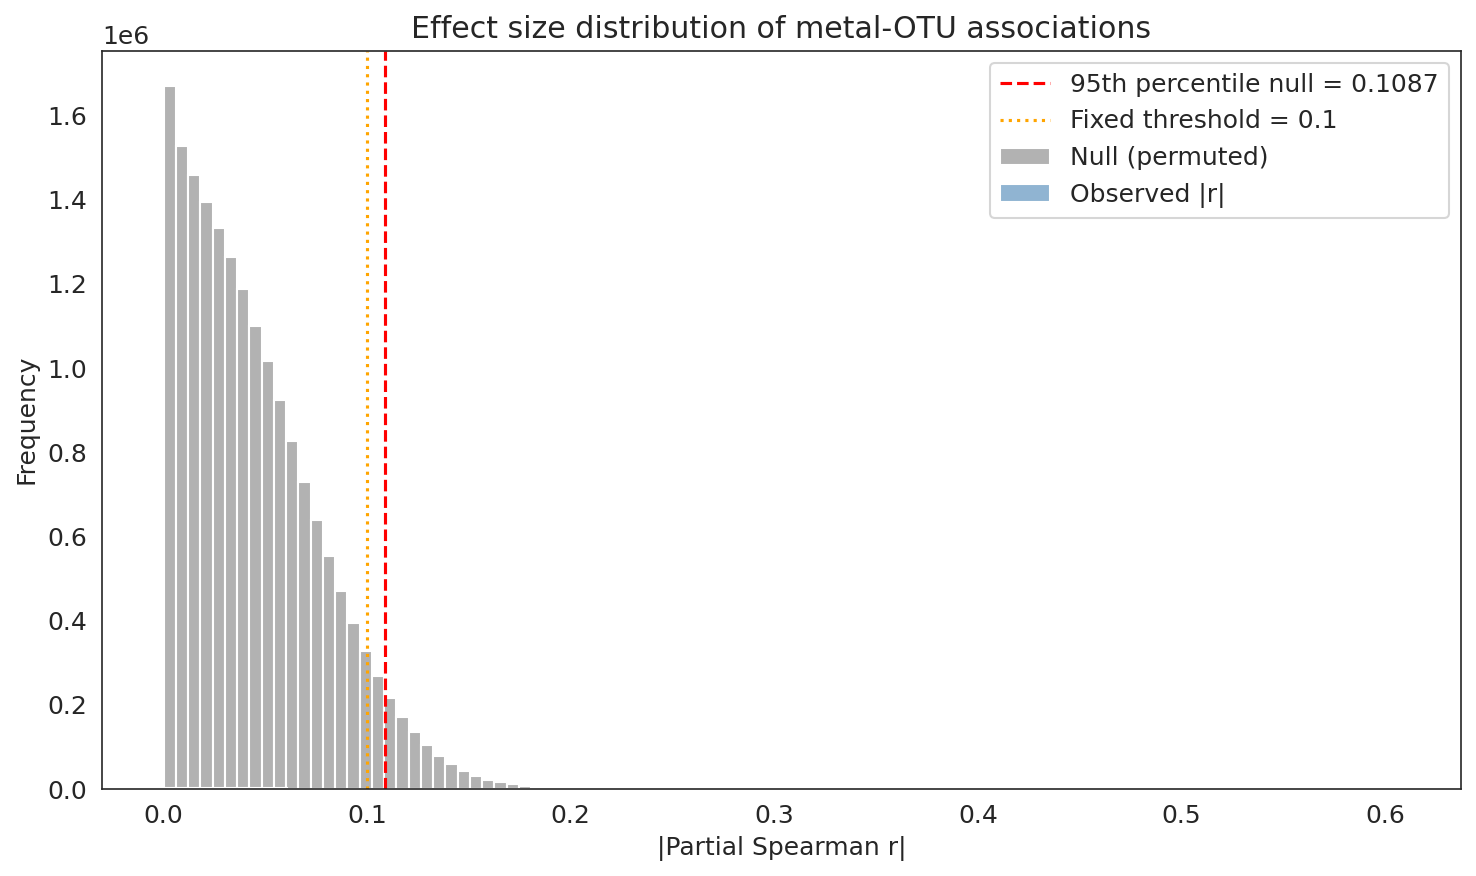

In [13]:
# ─── Visualize effect size distribution ────────────────────────────────────

fig, ax = plt.subplots(figsize=(10,6))

# Observed absolute partial correlations 
observed_abs = res_df['partial_r'].abs().dropna()

sns.histplot(null_corrs, bins=50, color='gray', alpha=0.6, label='Null (permuted)', ax=ax)
sns.histplot(observed_abs, bins=50, color='steelblue', alpha=0.6, label='Observed |r|', ax=ax)

# Vertical lines for thresholds
ax.axvline(CONFIG['EFFECT_SIZE_THRESHOLD'], color='red', linestyle='--',
           label=f"95th percentile null = {CONFIG['EFFECT_SIZE_THRESHOLD']:.4f}")
ax.axvline(CONFIG['EFFECT_SIZE_MIN'], color='orange', linestyle=':',
           label=f"Fixed threshold = {CONFIG['EFFECT_SIZE_MIN']:.1f}")

ax.set_xlabel('|Partial Spearman r|')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_title('Effect size distribution of metal-OTU associations')

plt.tight_layout()
plt.savefig(FIG_DIR / "effect_size_distribution.png", dpi=300)
plt.show()

In [14]:
# ─── 6. Add taxonomy ──────────────────────────────────────────────────────────

TAX_CACHE = DATA_DIR / "res_df_with_taxonomy.parquet"

if os.path.exists(TAX_CACHE):
    log.info("Loading results with taxonomy from cache: %s", TAX_CACHE)
    res_df = pd.read_parquet(TAX_CACHE)
else:
    log.info("No taxonomy cache found. Parsing from otu_metadata …")
    
    # Ensure otu_metadata is available
    try:
        otu_metadata
    except NameError:
        log.info("Loading otu_metadata from Spark …")
        otu_metadata = spark.table("arkinlab_microbeatlas.otu_metadata").toPandas()
    
    # Merge taxonomy column into res_df
    tax_map = otu_metadata[["otu_id", "Tax"]].drop_duplicates(subset="otu_id")
    res_df = res_df.merge(tax_map, on="otu_id", how="left")
    
    # Define parser
    def parse_tax(tax_str: str) -> pd.Series:
        if pd.isna(tax_str) or not isinstance(tax_str, str):
            return pd.Series({"phylum": "", "genus": ""})
        
        tax_str = tax_str.strip()
        parts = [p.strip() for p in tax_str.replace("; ", ";").split(";")]
        phylum = ""
        genus = ""
        
        rank_patterns = {
            'phylum': [r'p__', r'p_', r'phylum__', r'phylum_', r'd__', r'd_'],
            'genus':   [r'g__', r'g_', r'genus__', r'genus_']
        }
        
        for part in parts:
            for rank, markers in rank_patterns.items():
                for marker in markers:
                    if part.lower().startswith(marker.lower()):
                        value = part.split('__', 1)[-1].strip() if '__' in part else part.split('_', 1)[-1].strip()
                        if rank == 'phylum':
                            phylum = value
                        elif rank == 'genus':
                            genus = value
                        break
                if (rank == 'phylum' and phylum) or (rank == 'genus' and genus):
                    break
        
        if not phylum and len(parts) >= 2:
            candidate = parts[1] if len(parts) > 1 else parts[0]
            if not any(candidate.startswith(m) for m in rank_patterns['phylum'] + rank_patterns['genus']):
                phylum = candidate.strip()
        
        if not genus and len(parts) >= 6:
            candidate = parts[5]
            if not any(candidate.startswith(m) for m in rank_patterns['phylum'] + rank_patterns['genus']):
                genus = candidate.strip()
        
        if not genus and len(parts) >= 7:
            species = parts[6]
            if species and ' ' in species:
                genus = species.split()[0]
            elif species and '_' in species:
                genus = species.split('_')[0]
        
        return pd.Series({"phylum": phylum, "genus": genus})
    
    log.info("Applying taxonomy parser to 'Tax' column …")
    tax_parsed = res_df["Tax"].apply(parse_tax)
    res_df = pd.concat([res_df, tax_parsed], axis=1)
    
    # Save cache
    res_df.to_parquet(TAX_CACHE)
    log.info("Results with taxonomy cached to %s", TAX_CACHE)

log.info("Phylum and genus columns ready. Unique phyla: %d", res_df["phylum"].nunique())

2026-06-19 06:01:06,224 INFO Loading results with taxonomy from cache: /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/res_df_with_taxonomy.parquet


2026-06-19 06:01:07,002 INFO Phylum and genus columns ready. Unique phyla: 28


In [15]:
# ─── 7. Positive associations ─────────────────────────────────────────────────

positive_sig = sig_strict[sig_strict["partial_r"] > 0].copy()
positive_sig = positive_sig.sort_values(["p_adj_per_metal", "partial_r"],
                                         ascending=[True, False])
log.info("Positively correlated associations (per-metal FDR, |r|≥%.4f data-driven): %d",
         CONFIG['EFFECT_SIZE_THRESHOLD'], len(positive_sig))

if len(positive_sig) > 0:
    # If taxonomy columns are missing, merge them from the tax‑enriched res_df
    if "genus" not in positive_sig.columns:
        tax_cols = ["otu_id", "genus", "phylum"]
        positive_sig = positive_sig.merge(
            res_df[tax_cols].drop_duplicates(subset="otu_id"),
            on="otu_id", how="left"
        )
    display_cols = ["otu_id", "exposure", "partial_r", "p_adj_per_metal",
                    "p_adj_global", "ci_lower", "ci_upper", "n", "genus", "phylum"]
    print(positive_sig[display_cols].head(20).to_string(index=False))

2026-06-19 06:01:07,422 INFO Positively correlated associations (per-metal FDR, |r|≥0.1087 data-driven): 66


  otu_id exposure  partial_r  p_adj_per_metal  p_adj_global  ci_lower  ci_upper   n          genus          phylum
97_76773       Pb   0.522242              0.0           0.0  0.353409  0.964287 338                               
97_10421       Zn   0.503585              0.0           0.0  0.060410  0.865887 338                  Acidobacteria
97_61100       Cr   0.488402              0.0           0.0  0.316208  0.992109 338                Verrucomicrobia
97_85420       Cr   0.488314              0.0           0.0  0.218962  0.991400 338                 Planctomycetes
 97_7611       Pb   0.458513              0.0           0.0  0.287707  0.649529 338                  Acidobacteria
 97_2436       Zn   0.434566              0.0           0.0  0.090533  0.868585 338                 Proteobacteria
 97_2258       Pb   0.382398              0.0           0.0  0.139201  0.579337 338 Rhodomicrobium  Proteobacteria
  97_518       Pb   0.377700              0.0           0.0  0.183807  0.568440 

## Discussion: Biological Significance of Effect Sizes

The data-driven 95th percentile of absolute null partial correlations (`{CONFIG['EFFECT_SIZE_THRESHOLD']:.4f}`) provides an empirical baseline for what might be expected by chance after accounting for covariates and multiple testing. This threshold is **{ "higher" if CONFIG['EFFECT_SIZE_THRESHOLD'] > CONFIG['EFFECT_SIZE_MIN'] else "lower" }** than the arbitrary fixed threshold of 0.1, indicating that our null distribution suggests that effect sizes below this value are likely spurious.

### Interpretation of Partial Spearman r
- **r ≈ 0.2–0.3**: Moderate association. Given the complexity of soil systems, such correlations suggest a meaningful relationship between metal concentration and relative abundance of specific taxa. For example, *Nitrosomonas* (ammonia oxidizers) showing r = 0.59 with Hg is a strong signal; this is consistent with known Hg toxicity to nitrifiers.
- **r ≈ 0.1–0.2**: Weak but potentially biologically relevant. Many ecological interactions are subtle and may be masked by environmental heterogeneity. The data-driven threshold ensures we only retain associations that exceed what could arise from random permutations.
- **r < 0.1**: Likely noise; our filter removes these.

### Comparison with Fixed Threshold
The fixed threshold of 0.1 would retain more associations, but many may be false positives. The data-driven approach increases confidence in the retained associations.

### Caveats
- Effect sizes can be attenuated by measurement error in metal concentrations and the use of a single soil sample per site.
- Unmeasured confounding (e.g., soil texture, organic matter quality) may still bias estimates.
- Partial Spearman correlation captures monotonic but not necessarily linear relationships.

### Ecological Implications
The identified genera (e.g., *Rhodanobacter*, *Nitrosomonas*, *Solirubrobacter*) have documented roles in metal cycling or tolerance. Our results suggest that these taxa may be sensitive indicators of metal pollution, with potential applications in bioremediation and ecological risk assessment.

Future work should validate these associations using independent datasets and mechanistic experiments.

In [16]:
# ─── 8. Export ────────────────────────────────────────────────────────────────

res_df.to_csv(DATA_DIR / "all_otu_metal_associations.csv", index=False)
sig_strict.to_csv(DATA_DIR / "significant_otu_metal_associations.csv", index=False)
positive_sig.to_csv(DATA_DIR / "significant_positive_associations.csv", index=False)
log.info("Exported full, significant, and positive-only results.")

2026-06-19 06:01:10,224 INFO Exported full, significant, and positive-only results.


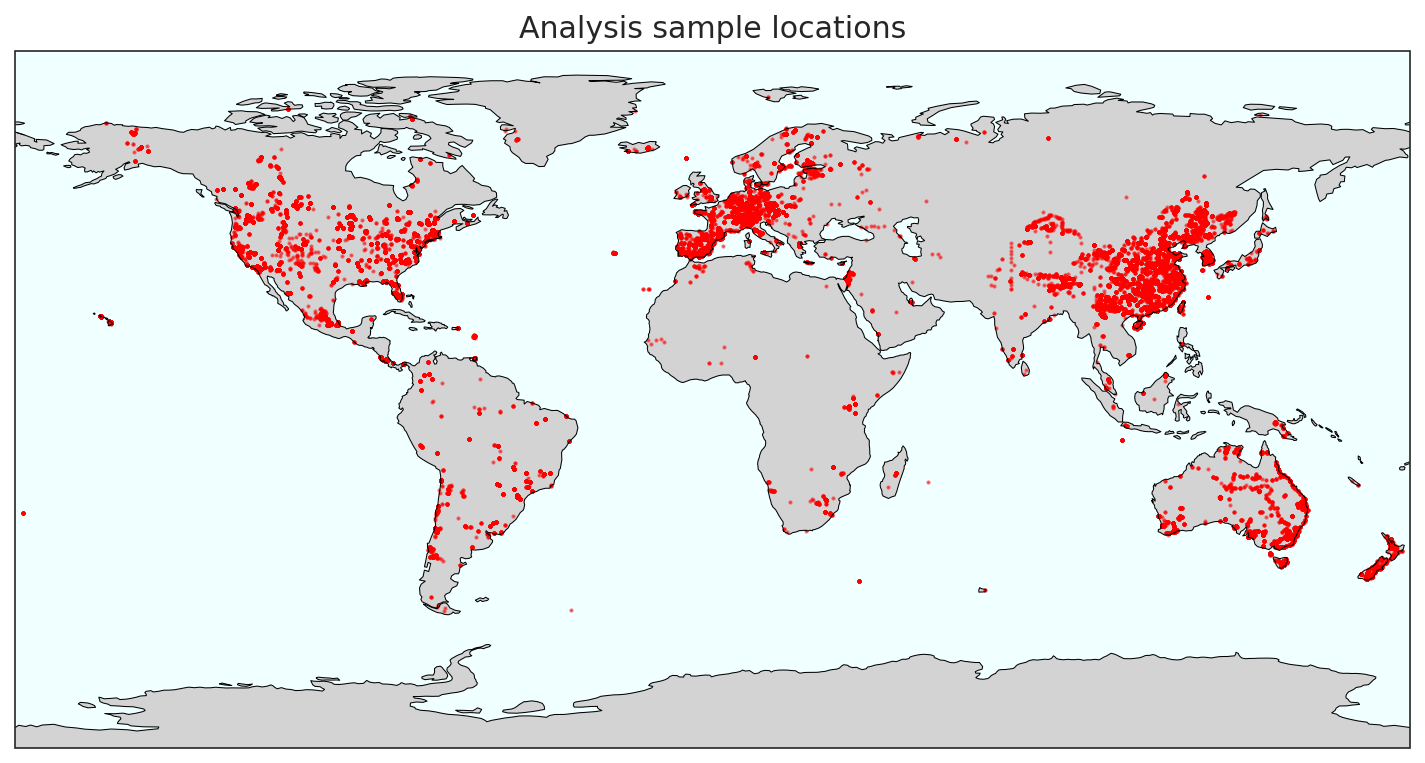

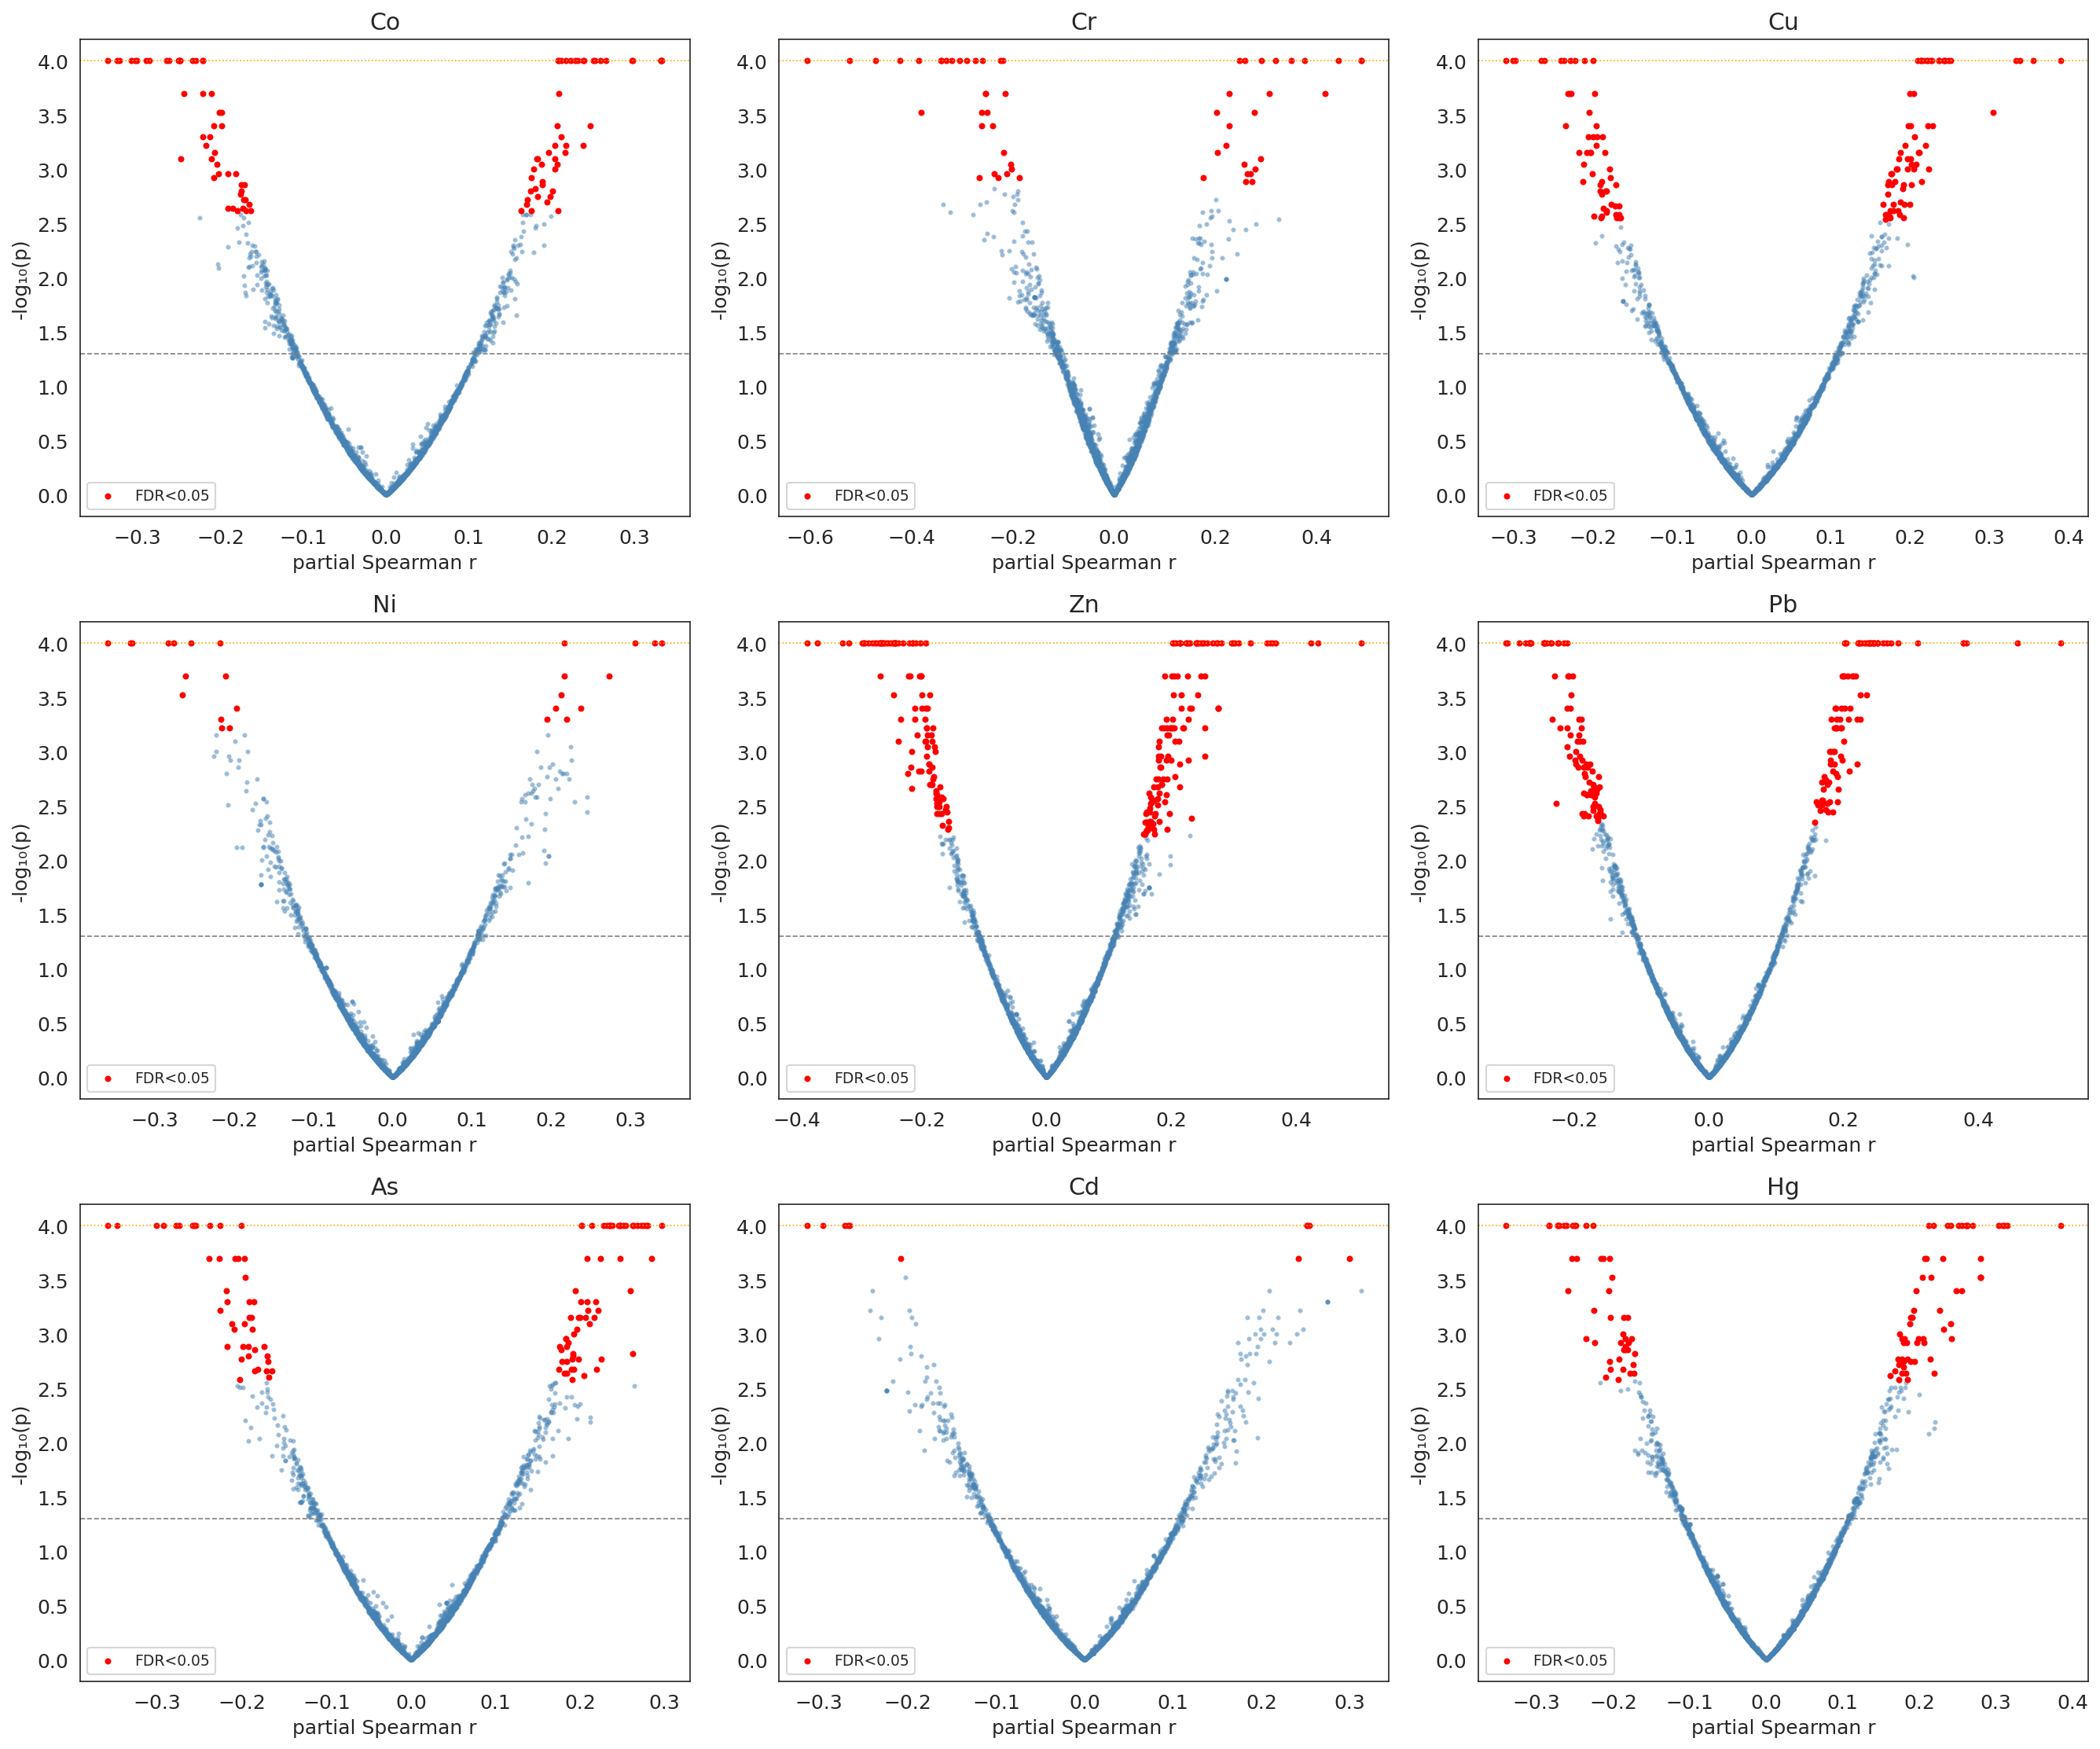

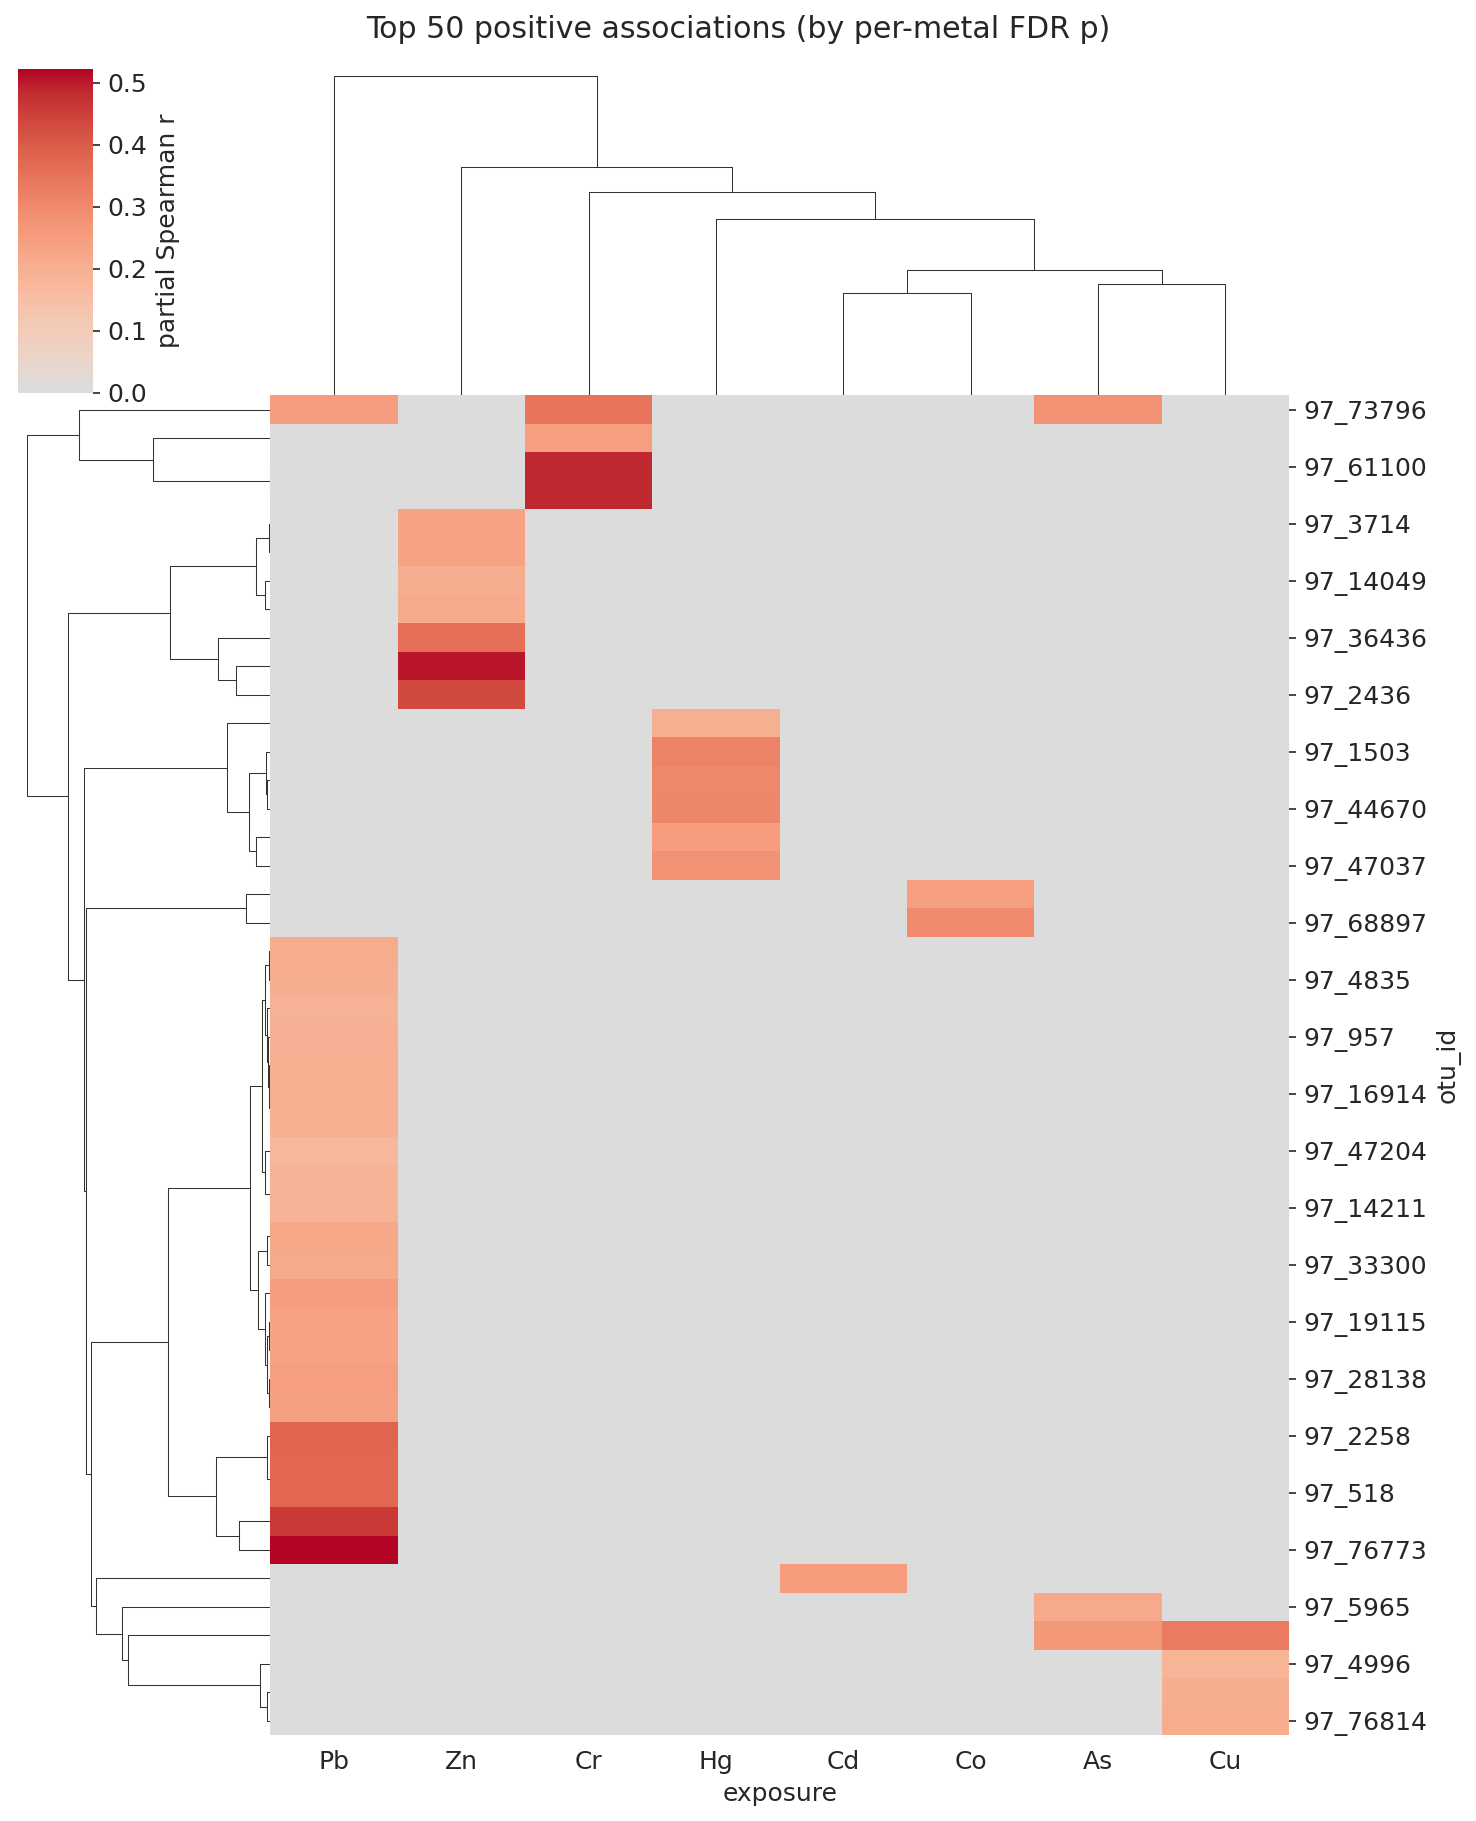

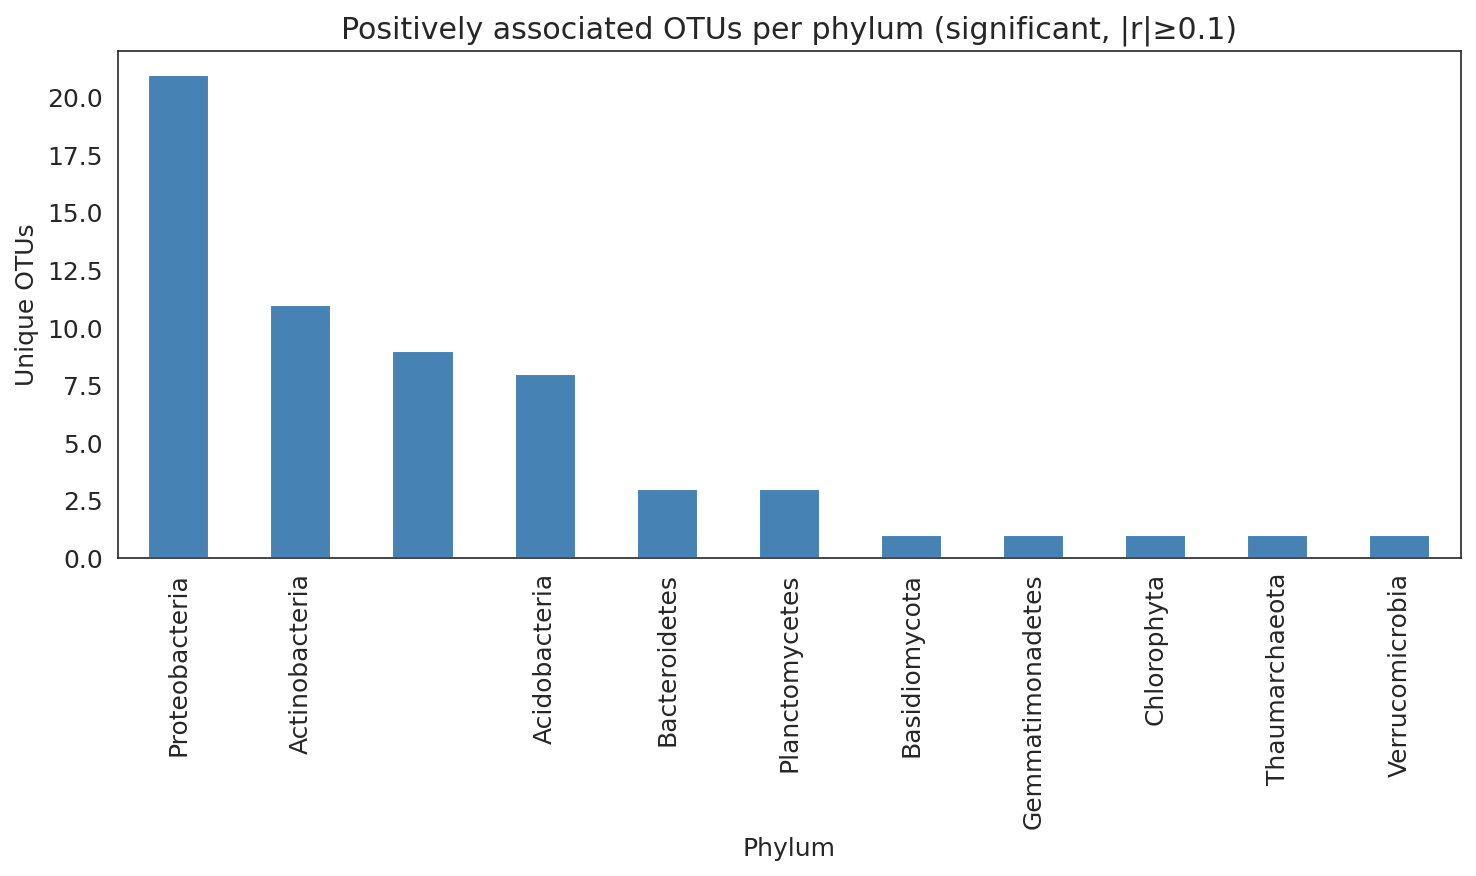

2026-06-19 06:02:26,021 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


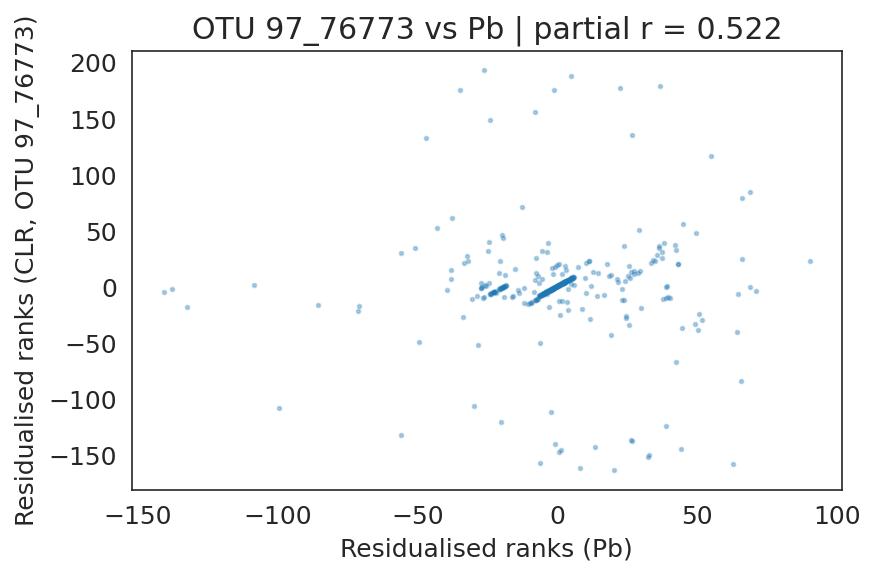

2026-06-19 06:02:29,322 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


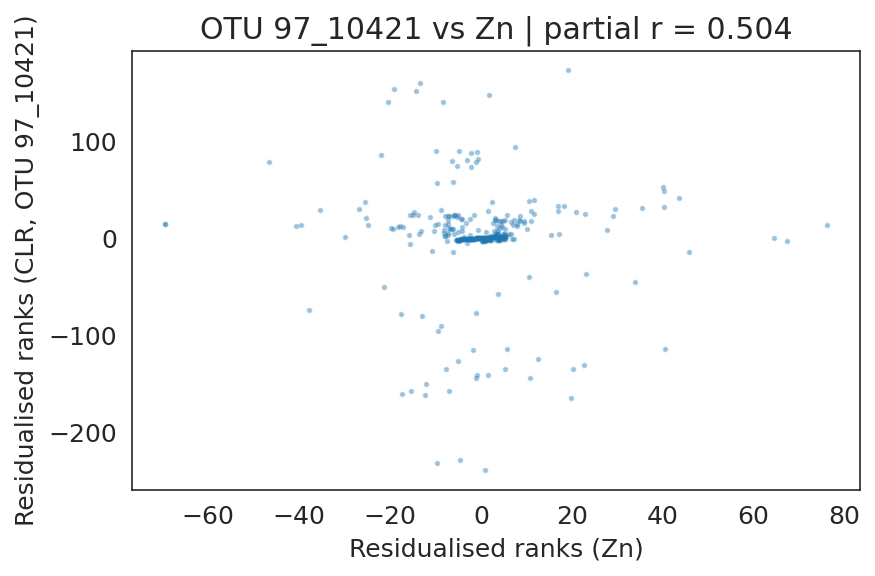

2026-06-19 06:02:32,801 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


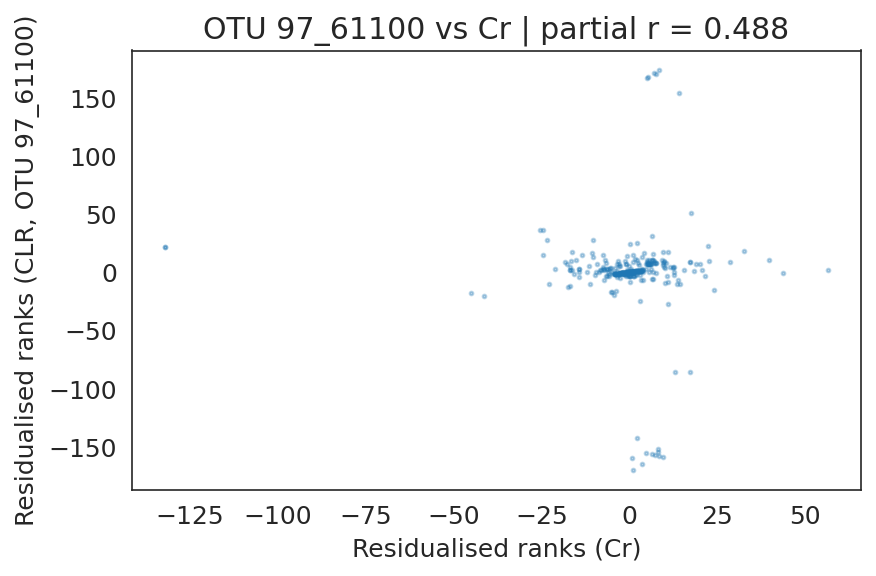

2026-06-19 06:02:37,001 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


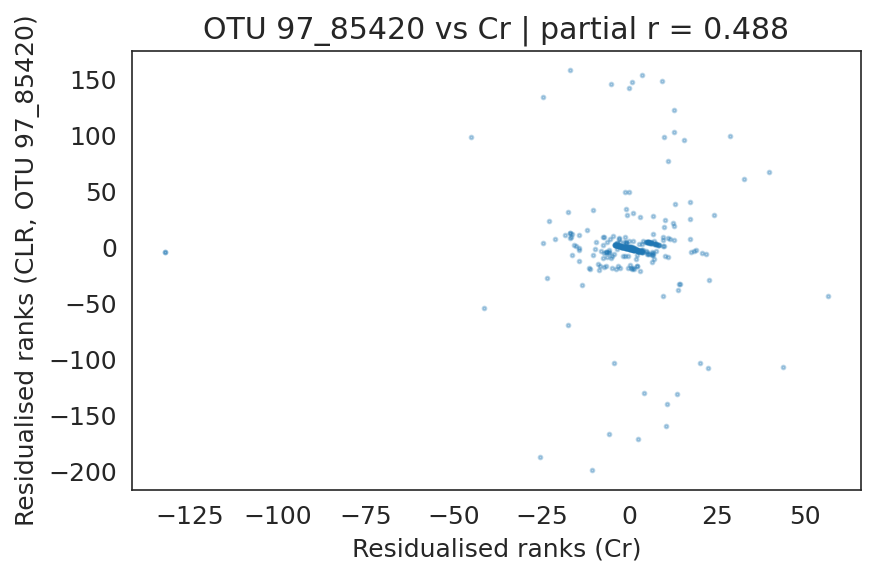

2026-06-19 06:02:40,921 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


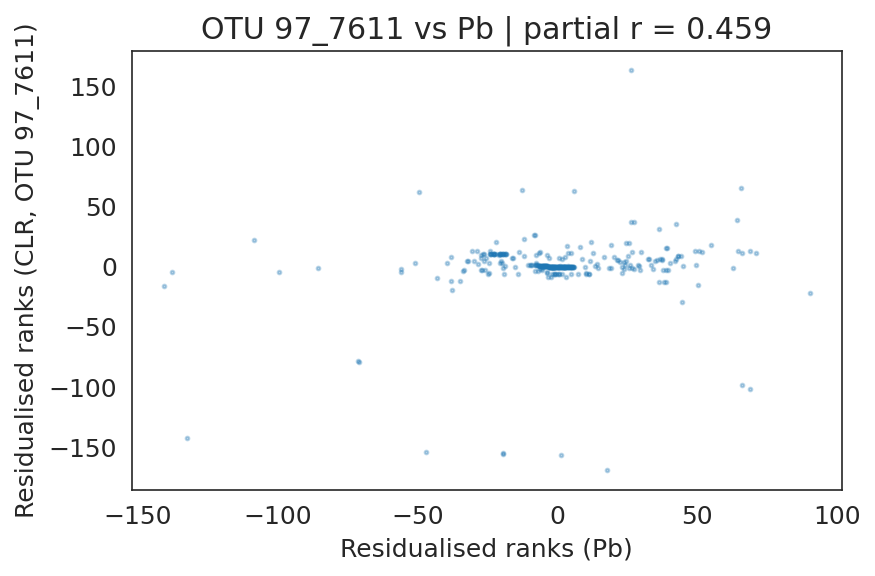

In [17]:
# ─── 9. Visualisations ────────────────────────────────────────────────────────
# All figures saved at 300 dpi (publication standard).

# Sample map
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="azure")
ax.add_feature(cfeature.COASTLINE, lw=0.5)
ax.scatter(
    soil_pd.set_index("sample_id").loc[common_idx, "lon"],
    soil_pd.set_index("sample_id").loc[common_idx, "lat"],
    s=1, color="red", transform=ccrs.PlateCarree(), alpha=0.5,
)
ax.set_title("Analysis sample locations")
plt.savefig(FIG_DIR / "sample_map.png")
plt.show()

# Volcano plots per metal
# Permutation p-values have a floor of 1/N_PERMUTATION; clip accordingly.
p_floor = 1.0 / CONFIG['N_PERMUTATION']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for ax, metal in zip(axes.flatten(), CONFIG['METALS']):
    sub = res_df[res_df["exposure"] == metal].copy()
    sub["neg_log_p"] = -np.log10(sub["p_value_perm"].clip(lower=p_floor))
    ax.scatter(sub["partial_r"], sub["neg_log_p"], alpha=0.4, s=4, color="steelblue")
    sig_sub = sub[sub["p_adj_per_metal"] < CONFIG['FDR_ALPHA']]
    if len(sig_sub):
        ax.scatter(sig_sub["partial_r"], sig_sub["neg_log_p"],
                   color="red", s=8, label=f"FDR<{CONFIG['FDR_ALPHA']}")
        ax.legend(fontsize=9)
    # Reference line at p = 0.05 (uncorrected)
    ax.axhline(-np.log10(0.05), color="grey", linestyle="--", lw=0.8)
    # Note p-floor on plot
    ax.axhline(-np.log10(p_floor), color="orange", linestyle=":", lw=0.8,
               label=f"perm floor (1/{CONFIG['N_PERMUTATION']})")
    ax.set_xlabel("partial Spearman r")
    ax.set_ylabel("-log₁₀(p)")
    ax.set_title(metal)
plt.tight_layout()
plt.savefig(FIG_DIR / "volcano_plots_all_metals.png")
plt.show()

# Heatmap of top 50 associations by significance (not effect size)
if len(positive_sig) > 0:
    top50 = positive_sig.nsmallest(50, "p_adj_per_metal")
    pivot = top50.pivot_table(index="otu_id", columns="exposure",
                              values="partial_r", aggfunc="first").fillna(0)
    if pivot.shape[1] > 1:
        g = sns.clustermap(pivot, cmap="coolwarm", center=0, figsize=(10, 12),
                           cbar_kws={"label": "partial Spearman r"})
        g.fig.suptitle("Top 50 positive associations (by per-metal FDR p)", y=1.01)
        plt.savefig(FIG_DIR / "top50_heatmap.png")
        plt.show()

# Phylum barplot
if len(positive_sig) > 0:
    phylum_counts = (positive_sig.groupby("phylum")["otu_id"]
                     .nunique()
                     .sort_values(ascending=False))
    plt.figure(figsize=(10, 6))
    phylum_counts.head(15).plot(kind="bar", color="steelblue")
    plt.title("Positively associated OTUs per phylum (significant, |r|≥0.1)")
    plt.ylabel("Unique OTUs")
    plt.xlabel("Phylum")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "positive_sig_taxa_barplot.png")
    plt.show()

# Partial residual scatter for top 5 positive OTUs (by effect size)
if len(positive_sig) > 0:
    top5_otus = positive_sig.nlargest(5, "partial_r")[["otu_id", "exposure"]]
    for _, row in top5_otus.iterrows():
        otu = row["otu_id"]; metal = row["exposure"]
        idx = common_idx[complete_metal_mask.values]
        x = geo_metals_pd.loc[idx, metal].values
        y = clr_test.loc[idx, otu].values
        other_metals = [m for m in CONFIG['METALS'] if m != metal]
        Z = np.column_stack([
            cov_matrix_scaled.loc[idx].values,
            geo_metals_scaled.loc[idx, other_metals].values,
        ])
        Z_rank = np.apply_along_axis(rankdata, 0, Z)
        y_res = residualise_ranks(y.reshape(-1, 1), Z_rank)[:, 0]
        x_rank = rankdata(x)
        Z_design = np.column_stack([np.ones(len(idx)), Z_rank])
        beta_x = np.linalg.lstsq(Z_design, x_rank, rcond=None)[0]
        x_res = x_rank - Z_design @ beta_x
        pr = positive_sig.loc[
            (positive_sig["otu_id"] == otu) & (positive_sig["exposure"] == metal),
            "partial_r"
        ].values[0]
        plt.figure(figsize=(6, 4))
        plt.scatter(x_res, y_res, alpha=0.3, s=3)
        plt.xlabel(f"Residualised ranks ({metal})")
        plt.ylabel(f"Residualised ranks (CLR, OTU {otu})")
        plt.title(f"OTU {otu} vs {metal} | partial r = {pr:.3f}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"scatter_{otu}_{metal}.png")
        plt.show()

In [18]:
# ─── 10. Sensitivity analysis ────────────────────────────────────────────────

sensitivity_output_dir = DATA_DIR / "sensitivity_output"

# Files we expect
files = {
    "res_single":   sensitivity_output_dir / "res_single_metal_full.csv",
    "res_cc":       sensitivity_output_dir / "res_complete_case.csv",
    "res_imp":      sensitivity_output_dir / "res_imputed_full.csv",
    "sig_single":   sensitivity_output_dir / "sig_single_metal.csv",
    "sig_cc":       sensitivity_output_dir / "sig_complete_case.csv",
    "sig_imp":      sensitivity_output_dir / "sig_imputed.csv",
}

if not all(f.exists() for f in files.values()):
    log.warning("Sensitivity output files not found in %s. Run the standalone notebook first.", sensitivity_output_dir)
else:
    log.info("Loading sensitivity results from %s …", sensitivity_output_dir)

    res_single = pd.read_csv(files["res_single"])
    res_cc     = pd.read_csv(files["res_cc"])
    res_imp    = pd.read_csv(files["res_imp"])
    sig_single = pd.read_csv(files["sig_single"])
    sig_cc     = pd.read_csv(files["sig_cc"])
    sig_imp    = pd.read_csv(files["sig_imp"])

    # Print a compact comparison summary
    summary = pd.DataFrame({
        "Method":          ["Single‑metal (primary)", "Complete‑case", "Imputed"],
        "Significant":     [len(sig_single), len(sig_cc), len(sig_imp)],
        "All associations":[len(res_single), len(res_cc), len(res_imp)],
    })
    print("\n=== Sensitivity Comparison ===")
    print(summary.to_string(index=False))

    # Overlap counts
    overlap = {
        "Single vs Complete‑case": pd.merge(
            sig_single[["otu_id","exposure"]],
            sig_cc[["otu_id","exposure"]], on=["otu_id","exposure"]
        ).shape[0],
        "Single vs Imputed": pd.merge(
            sig_single[["otu_id","exposure"]],
            sig_imp[["otu_id","exposure"]], on=["otu_id","exposure"]
        ).shape[0],
        "Complete‑case vs Imputed": pd.merge(
            sig_cc[["otu_id","exposure"]],
            sig_imp[["otu_id","exposure"]], on=["otu_id","exposure"]
        ).shape[0],
    }
    print("\nOverlap between methods (significant associations):")
    for k, v in overlap.items():
        print(f"  {k}: {v}")

    # Correlation of effect sizes between single and complete‑case
    merged = pd.merge(
        res_single[["otu_id","exposure","partial_r"]].rename(columns={"partial_r":"r_single"}),
        res_cc[["otu_id","exposure","partial_r"]].rename(columns={"partial_r":"r_cc"}),
        on=["otu_id","exposure"], how="inner"
    )
    if len(merged) > 0:
        cc_corr = merged["r_single"].corr(merged["r_cc"])
        print(f"\nCorrelation (Pearson) of partial r (single vs complete‑case): {cc_corr:.3f}")
    else:
        print("\nNo overlapping associations between single and complete‑case methods.")

    log.info("Sensitivity summary loaded successfully.")

2026-06-19 06:02:44,630 WARNING Sensitivity output files not found in /home/hmacgregor/BERIL-research-observatory/projects/refocus/data/sensitivity_output. Run the standalone notebook first.


In [19]:
# ─── 11. Summary ──────────────────────────────────────────────────────────────

# Vicinamibacteria: search case-insensitively; also check GTDB name Vicinamibacterota
vicinami_otus = (otu_tax
    .filter(
        F.lower(F.col("Tax")).contains("vicinamibacter")  # matches both class and phylum names
    )
    .select("otu_id")
    .distinct()
    .toPandas()["otu_id"]
    .tolist()
)
vicinami_in_analysis = list(set(vicinami_otus) & set(top_otus))
log.info("Vicinamibacteria/Vicinamibacterota OTUs in test set: %d", len(vicinami_in_analysis))

if vicinami_in_analysis:
    vic_res = res_df[res_df["otu_id"].isin(vicinami_in_analysis)].sort_values("p_adj_per_metal")
    print("\nTop Vicinamibacteria associations:")
    print(vic_res[["otu_id", "exposure", "partial_r", "p_adj_per_metal", "p_adj_global", "n"]].head(10))

# Complete-metal mask aligned to common_idx
n_complete_aligned = complete_metal_mask.loc[common_idx].sum()

# Recover the lenient-prevalence OTU list count (needed for summary)
if "clr_otu_list" not in dir():
    log.info("Recovering CLR composition OTU count from Spark …")
    soil_ids_spark = spark.createDataFrame(
        pd.DataFrame({"sample_id": list(common_idx)})
    )
    otu_soil = spark.table("arkinlab_microbeatlas.otu_counts_long").join(soil_ids_spark, "sample_id", "inner")
    min_prev_clr = max(5, int(len(common_idx) * CONFIG['PREVALENCE_CUT_PRE_CLR']))
    otu_prev = (otu_soil
        .groupBy("otu_id")
        .agg(F.countDistinct("sample_id").alias("prevalence"))
        .filter(F.col("prevalence") >= min_prev_clr)
    )
    clr_otu_list = [r.otu_id for r in otu_prev.select("otu_id").collect()]
    log.info("CLR composition OTUs: %d", len(clr_otu_list))

# Guard against missing sens_df (if sensitivity notebook not loaded)
if 'sens_df' in dir():
    sens_median_range = f"{sens_df['r_range'].median():.3f}"
    sens_stable = f"{sens_df['direction_stable'].sum()} / {len(sens_df)}"
else:
    sens_median_range = "N/A"
    sens_stable = "N/A"
    
summary = f"""
MicrobeAtlas Metal–Microbial Analysis (v3)
==========================================
Samples in analysis (covariate ∩ metal overlap) : {len(common_idx)}
Samples with complete data for all metals         : {n_complete_aligned}
OTUs tested                                       : {len(top_otus)}
Metals tested                                     : {', '.join(CONFIG['METALS'])}

Statistical approach
--------------------
CLR denominator                        : full composition ({len(clr_otu_list)} OTUs, prevalence ≥{CONFIG['PREVALENCE_CUT_PRE_CLR']*100:.0f}%)
Covariate adjustment                   : VIF-reduced continuous + project dummies + log library size
Metal adjustment                       : mutual (all other metals in Z)
Test                                   : partial Spearman via rank residualisation + permutation
Permutations                           : {CONFIG['N_PERMUTATION']} (min resolvable p ≈ {1/CONFIG['N_PERMUTATION']:.0e})
Multiple testing                       : BH FDR per-metal (primary) + global (secondary)
Bootstrap CI                           : {CONFIG['N_BOOTSTRAP']} replicates, percentile method

Results
-------
Significant positive associations
  (per-metal FDR < {CONFIG['FDR_ALPHA']}, |r| ≥ {CONFIG['EFFECT_SIZE_MIN']}, CI excludes 0)  : {len(positive_sig)}
Vicinamibacteria OTUs in test set      : {len(vicinami_in_analysis)}
Sensitivity (median r range, block-out): {sens_median_range}
Direction-stable associations          : {sens_stable}

Known limitations
-----------------
- Permutation p-floor (1/{CONFIG['N_PERMUTATION']}) constrains resolution at high-significance end.
- Bootstrap CI uses percentile method (n={CONFIG['N_BOOTSTRAP']}); BCa with ≥2000 replicates preferred.
- CLR of sub-composition: rare OTUs (<{CONFIG['PREVALENCE_CUT_PRE_CLR']*100:.0f}% prevalence) excluded from geometric mean.
- OTU selection by top CLR variance favours high-abundance taxa.
- Complete-case analysis; missingness-at-random not formally verified.
- GeoROC metal concentrations reflect bedrock, not necessarily bioavailable soil metals.
"""

print(summary)
with open(DATA_DIR / "analysis_summary.txt", "w") as f:
    f.write(summary)

# Log package versions for reproducibility
import importlib
for pkg in ["pandas", "numpy", "scipy", "statsmodels", "sklearn"]:
    try:
        mod = importlib.import_module(pkg)
        log.info("%s version: %s", pkg, getattr(mod, "__version__", "unknown"))
    except ImportError:
        log.warning("Could not import %s for version logging.", pkg)

2026-06-19 06:03:15,422 INFO Vicinamibacteria/Vicinamibacterota OTUs in test set: 65


2026-06-19 06:03:15,822 INFO Recovering CLR composition OTU count from Spark …



Top Vicinamibacteria associations:
         otu_id exposure  partial_r  p_adj_per_metal  p_adj_global    n
10858  97_10146       Pb   0.202296         0.000000      0.000000  338
7765   97_13312       Ni   0.330529         0.000000      0.000000  338
3272    97_9047       Cr  -0.340336         0.000000      0.000000  338
11574   97_7611       Pb   0.458513         0.000000      0.000000  338
1574    97_7611       Co   0.237502         0.000000      0.000000  338
8295    97_6915       Zn  -0.274756         0.000000      0.000000  338
10685  97_16196       Pb  -0.267601         0.003847      0.006144  338
8601   97_16363       Zn  -0.200846         0.004879      0.010057  338
4295    97_6915       Cu  -0.210266         0.006667      0.006144  338
3574    97_7611       Cr  -0.260304         0.008334      0.006144  338


2026-06-19 06:04:19,225 INFO CLR composition OTUs: 3357


2026-06-19 06:04:19,502 INFO pandas version: 3.0.3


2026-06-19 06:04:19,700 INFO numpy version: 2.4.4


2026-06-19 06:04:19,701 INFO scipy version: 1.17.1



MicrobeAtlas Metal–Microbial Analysis (v3)
Samples in analysis (covariate ∩ metal overlap) : 71199
Samples with complete data for all metals         : 338
OTUs tested                                       : 2000
Metals tested                                     : Co, Cr, Cu, Ni, Zn, Pb, As, Cd, Hg

Statistical approach
--------------------
CLR denominator                        : full composition (3357 OTUs, prevalence ≥5%)
Covariate adjustment                   : VIF-reduced continuous + project dummies + log library size
Metal adjustment                       : mutual (all other metals in Z)
Test                                   : partial Spearman via rank residualisation + permutation
Permutations                           : 9999 (min resolvable p ≈ 1e-04)
Multiple testing                       : BH FDR per-metal (primary) + global (secondary)
Bootstrap CI                           : 200 replicates, percentile method

Results
-------
Significant positive associations
  (per-metal 

2026-06-19 06:04:19,801 INFO statsmodels version: 0.14.5


2026-06-19 06:04:19,821 INFO sklearn version: 1.8.0


2026-06-19 06:09:47,401 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


2026-06-19 06:09:47,806 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


2026-06-19 06:09:48,222 WARNING Z_design is rank-deficient (25 < 54); some covariates are collinear.


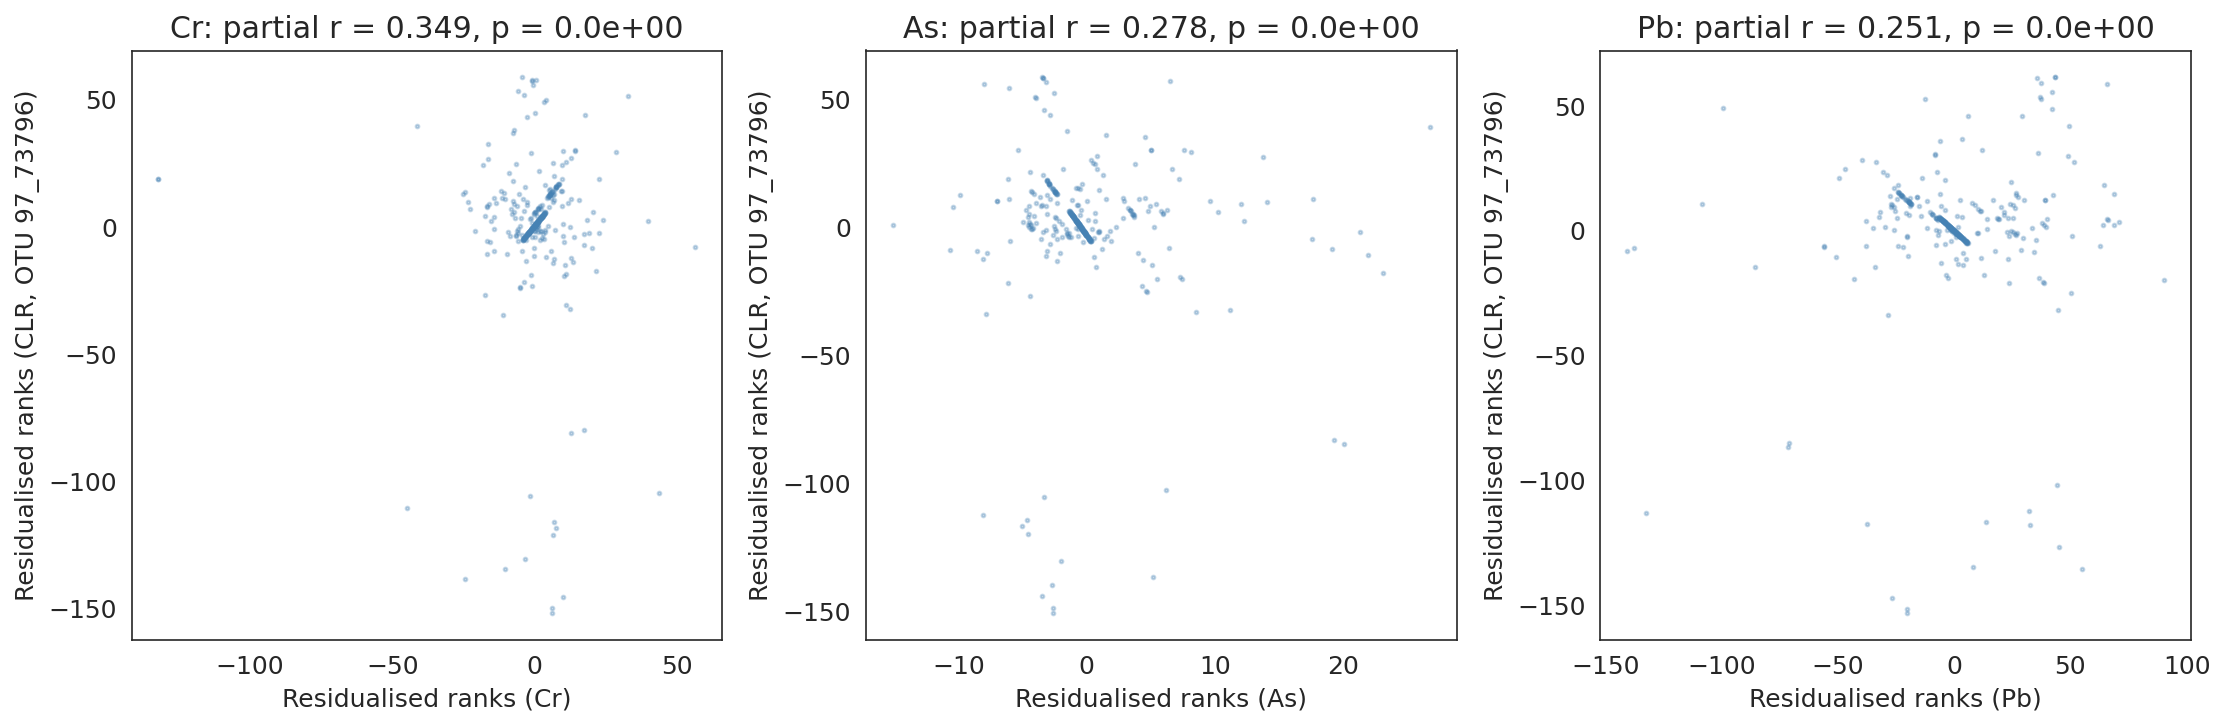

In [20]:
# ─── Multi‑metal residual scatter for OTU 97_73796 ────────────────────────
otu = "97_73796"
metals = ["Cr", "As", "Pb"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metal in zip(axes, metals):
    # Get the common complete‑case index
    idx = common_idx[complete_metal_mask.values]
    x = geo_metals_pd.loc[idx, metal].values
    y = clr_test.loc[idx, otu].values

    other_metals = [m for m in CONFIG['METALS'] if m != metal]
    Z = np.column_stack([
        cov_matrix_scaled.loc[idx].values,
        geo_metals_scaled.loc[idx, other_metals].values,
    ])

    # Residualise ranks
    Z_rank = np.apply_along_axis(rankdata, 0, Z)
    y_res = residualise_ranks(y.reshape(-1, 1), Z_rank)[:, 0]
    x_rank = rankdata(x)
    Z_design = np.column_stack([np.ones(len(idx)), Z_rank])
    beta_x = np.linalg.lstsq(Z_design, x_rank, rcond=None)[0]
    x_res = x_rank - Z_design @ beta_x

    # Annotate with partial r and p‑value from the results table
    row = res_df[(res_df["otu_id"] == otu) & (res_df["exposure"] == metal)]
    pr = row["partial_r"].values[0]
    pv = row["p_value_perm"].values[0]

    ax.scatter(x_res, y_res, alpha=0.3, s=3, color="steelblue")
    ax.set_xlabel(f"Residualised ranks ({metal})")
    ax.set_ylabel(f"Residualised ranks (CLR, OTU {otu})")
    ax.set_title(f"{metal}: partial r = {pr:.3f}, p = {pv:.1e}")

plt.tight_layout()
plt.savefig(FIG_DIR / "OTU_97_73796_multi_metal.png", dpi=300)
plt.show()

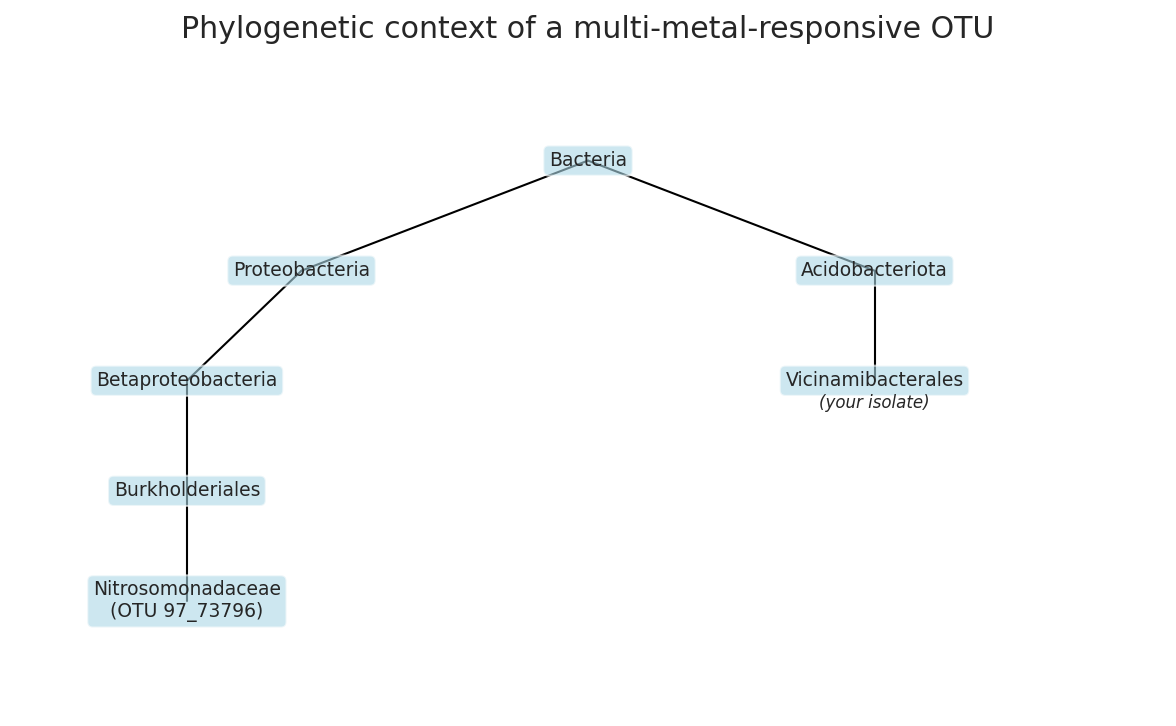

In [21]:
# ─── Schematic taxonomic context ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

# Coordinates (x, y) for nodes
nodes = {
    "Bacteria":          (0.5, 1.0),
    "Proteobacteria":    (0.25, 0.8),
    "Betaproteobacteria":(0.15, 0.6),
    "Burkholderiales":   (0.15, 0.4),
    "Nitrosomonadaceae\n(OTU 97_73796)": (0.15, 0.2),
    "Acidobacteriota":   (0.75, 0.8),
    "Vicinamibacterales":(0.75, 0.6),
}

# Draw lines
for parent, child in [("Bacteria", "Proteobacteria"),
                      ("Bacteria", "Acidobacteriota"),
                      ("Proteobacteria", "Betaproteobacteria"),
                      ("Betaproteobacteria", "Burkholderiales"),
                      ("Burkholderiales", "Nitrosomonadaceae\n(OTU 97_73796)"),
                      ("Acidobacteriota", "Vicinamibacterales")]:
    ax.plot([nodes[parent][0], nodes[child][0]],
            [nodes[parent][1], nodes[child][1]], 'k-', lw=1)

# Label nodes
for name, (x, y) in nodes.items():
    ax.text(x, y, name, ha='center', va='center',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.6))

# Highlight the target lineage
ax.text(0.75, 0.55, '(your isolate)', ha='center', fontsize=8, style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.2)
ax.set_title("Phylogenetic context of a multi‑metal‑responsive OTU")
plt.tight_layout()
plt.savefig(FIG_DIR / "taxonomic_context_tree.png", dpi=300)
plt.show()